# Library

In [1]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# 라이브러리 설치
!pip install --upgrade --no-cache-dir numpy seaborn
!pip install ydata_profiling
!pip install missingno
!pip install tqdm

!pip install tsfeatures
!pip install -U kss==5.2.0
!pip install kiwipiepy
!pip install soynlp
!pip install keybert
!pip install keybert[gensim]
!pip install sentence_transformers

!pip install nltk
!pip install konlpy
!pip install gensim
!pip install bertopic -U
!pip install bertopic[visualization] -U
!pip install -U accelerate
!pip install -U transformers
!pip install datasets

!pip install catboost
!pip install mlxtend
!pip install mlforecast
!pip install tensorflow==2.15 keras==2.15
!pip install keras-tqdm
!pip install neuralforecast
!pip install sktime[all_extras]
!pip install shap

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 270.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [1]:
# Auto reload of library
%load_ext autoreload
%autoreload 2

# System related and data input controls
import os

# Ignore the warnings
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Visualization
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
## 한글 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum* -qq
## NanumGothic 폰트 경로 지정
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
## 한글 폰트 설정
matplotlib.rcParams['font.family'] = font_prop.get_name()
plt.rc('font', family='NanumGothic')
sns.set(font=font_prop.get_name())
## 마이너스 표시 설정
plt.rcParams['axes.unicode_minus'] = False

# Custom
## 사용자의 실제 작업경로로 설정!
work_path = '/content/drive/MyDrive/Research/Analysis/Lecture/특강_20250412_한국지능정보사회진흥원_빅데이터센터'
os.chdir(work_path)
!ls
from module_KK import *

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126329 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


# Hyperparameter

In [2]:
# Data Preprocessing
folder_location = os.path.join(os.path.join('.', 'Data'))
Y_colname = '승차인원수'
RANDOM_STATE = 123
DATE_SPLITS = ['2023-03-31', '2024-03-31']
X_col_FUTR = ['일수', '주말수', '주중수', '공휴일수', '명절수',
              '공급좌석합계수', '승차율', '열차운행횟수',
              ## 미래는 코로나가 없다는 가정
              '사망자수', '접종시작자수', '격리된자수', '정부대응정도',
              '확진자수', '접종완료자수', '코로나진행정도', '국가이동제한정도',
              ## 인구정보는 현재와 변함이 없다는 가정
              '출생아수(명)', '사망자수(명)', '자연증가건수(명)', '조출생률(천명당)', '조사망률(천명당)',
              '자연증가율(천명당)', '합계출산율(명)', '출생성비(명)',
              '혼인건수(건)', '조혼인율(천명당)', '이혼건수(건)', '조이혼율(천명당)']
X_col_STATIC_ML = []
X_col_STATIC_DL = None

# Modeling
N_WINDOWS = 2
RANDOM_STATE = 123
VERBOSITY = 0

# Evaluation
RANKING_METRIC = ['MSPE', 'MAPE', 'MedAPE']

# Data Process Summary

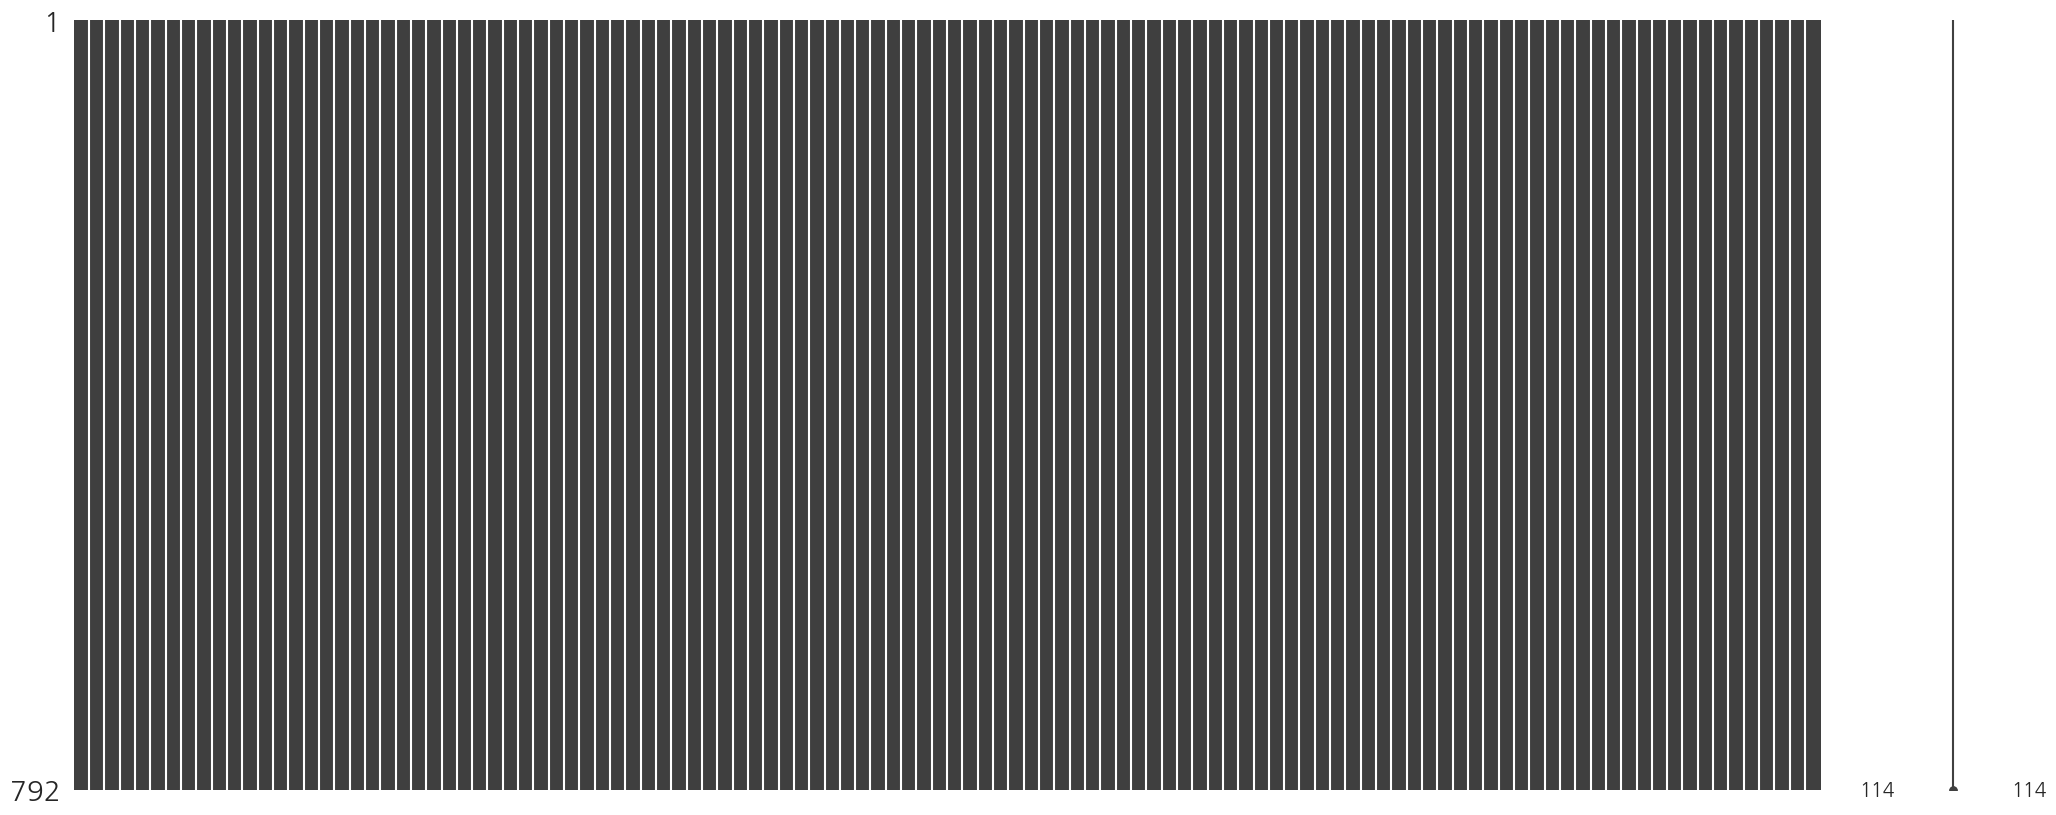

(99, 111) (12, 111) (21, 111)


In [3]:
# 데이터 준비
## 1) 비즈니스 데이터
df = pd.read_csv(os.path.join(folder_location, 'df_KTX_monthsum_example_KK.csv'), encoding='utf-8-sig')
df['Date'] = pd.to_datetime(df['Date'])
## 2) Econ 데이터
df_active = pd.read_excel(os.path.join(folder_location, 'ECON_경제활동인구_KK.xlsx'), sheet_name='데이터', header=7)
df_active['Date'] = pd.to_datetime(df_active['Date'])
df_sentiment = pd.read_excel(os.path.join(folder_location, 'ECON_소비자동향조사(전국, 월, 2008.9~)_KK.xlsx'), sheet_name='데이터', header=7)
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date'])
df_sentiment = df_sentiment.dropna(axis=1)
df_price = pd.read_excel(os.path.join(folder_location, 'ECON_소비자물가지수_KK.xlsx'), sheet_name='데이터', header=6)
df_price['Date'] = pd.to_datetime(df_price['Date'])
## 3) Kosis 데이터
df_traffic = pd.read_csv(os.path.join(folder_location, 'KOSIS_내국인출국교통수단별_KK.csv'), encoding='cp949', header=2)
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])
df_traffic['내국인출입국_공항'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '공항']].sum(axis=1).values
df_traffic['내국인출입국_항구'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '항구']].sum(axis=1).values
df_traffic.drop(columns=[col for col in df_traffic.columns if col.split('_')[0] in ['공항', '항구']], inplace=True)
df_entry = pd.read_csv(os.path.join(folder_location, 'KOSIS_외래객_입국목적별_국적별_KK.csv'), encoding='cp949', header=1)
df_entry['Date'] = pd.to_datetime(df_entry['Date'])
df_population = pd.read_csv(os.path.join(folder_location, 'KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼__KK.csv'), encoding='cp949', header=0)
df_population['Date'] = pd.to_datetime(df_population['Date'], format='%Y', errors='coerce')
df_population = df_population[[col for col in df_population.columns if col not in ['영아사망률(출생아 천명당)', '기대수명(출생시 기대여명)',
                                                                                   '기대수명(출생시 기대여명) - 남', '기대수명(출생시 기대여명) - 여']]]
## 뉴스 데이터
df_news = pd.read_excel(os.path.join(folder_location, 'NewsResult_20150101-20250331_KTX코레일.xlsx'), header=0)
df_news.rename(columns={'일자':'Date'}, inplace=True)
df_news['Date'] = pd.to_datetime(df_news['Date'], format='%Y%m%d')
df_news = df_news[['Date', '언론사', '통합 분류1', '제목', '본문']]
df_news = df_news.sort_values(by='Date', ascending=True).reset_index().iloc[:,1:]
## 4) 뉴스 트래픽 추출
df_news['Date_Group'] = df_news['Date'].apply(lambda x: str(x)[:7])
df_news_count = df_news.groupby('Date_Group')['제목'].count().reset_index()
df_news_count.rename(columns={'제목':'News_Count'}, inplace=True)
df_news_count['Date'] = pd.to_datetime(df_news_count.Date_Group, format='%Y-%m', errors='coerce')
df_news_count = df_news_count[['Date', 'News_Count']]
## 5) 감성 추출 데이터 정리
df_news_sentiment = pd.read_csv(os.path.join('.', 'Data', 'NewsResult_20150101-20250331_KTX코레일_Sentiment.csv'),
                                encoding='utf-8-sig')
df_news_sentiment['Sentiment'] = df_news_sentiment['Sentiment'].apply(lambda x: -1 if x==0 else 1)
## 일 -> 월 감성 집계
df_news_sentiment = pd.concat([df_news.Date, df_news.Date_Group, df_news_sentiment['Sentiment']], axis=1)
df_news_sentiment = df_news_sentiment.groupby('Date_Group')['Sentiment'].sum().reset_index()
df_news_sentiment['Date_Group'] = pd.to_datetime(df_news_sentiment.Date_Group, format='%Y-%m')
df_news_sentiment.rename(columns={'Date_Group':'Date'}, inplace=True)

# 데이터 결합
df = pd.merge(df, df_active, on='Date', how='left').fillna(0)
df = pd.merge(df, df_sentiment, on='Date', how='left').fillna(0)
df = pd.merge(df, df_price, on='Date', how='left').fillna(0)
df = pd.merge(df, df_traffic, on='Date', how='left').fillna(0)
df = pd.merge(df, df_entry, on='Date', how='left').fillna(0)
df = pd.merge(df, df_population, on='Date', how='left').fillna(method='ffill')
df = pd.merge(df, df_news_count, on='Date', how='left').fillna(0)
df = pd.merge(df, df_news_sentiment, on='Date', how='left').fillna(0)
## 변수명 좌우공백 제거
df.columns = [col.strip() for col in df.columns]

# 데이터 전처리
# 1) 불필요 변수 삭제
## 결측치의 비율이 50% 넘는 변수 삭제
## 변수의 값 종류가 1개인 변수 삭제
## 분석과 무관한 변수 삭제

# 2) 결측치 채우기
msno.matrix(df)
plt.show()

# 3) 대상노선 결정
df = df[(df['주운행선'] == '경부선') & (df['전체주중주말'] == '주말')]
df.drop(columns=['주운행선', '전체주중주말'], inplace=True)

# 4) Train, Validate, Test 분리
## 시간인덱스 설정
if 'Date' in df.columns:
  df.set_index('Date', inplace=True)
if len(DATE_SPLITS) == 2:
  df_train = df[df.index <= DATE_SPLITS[0]]
  df_validate = df[(df.index > DATE_SPLITS[0]) & (df.index <= DATE_SPLITS[1])]
  df_test = df[(df.index > DATE_SPLITS[1])]
print(df_train.shape, df_validate.shape, df_test.shape)

# 5) Y & X 분리
X_colname = [col for col in df.columns if col not in [Y_colname]]

# 6) 스케일링
## 시계열 딥러닝 알고리즘 내 포함되어 생략

# Modeling AI

| **모델링 종류** | **알고리즘 분야** | **이름** | **개발연도** |
|:---:|:---:|:---:|:---:|
| **Machine Learning** | **Bagging** | RandomForest | 2001 |
|  | **Boosting** | XGBoost | 2014 |
|  |  | LightGBM | 2016 |
|  |  | CatBoost | 2017 |
| **Deep Learning** | **MLP** | MLP | 2010 |
|  |  | NBEATS | 2019 |
|  |  | NHITS | 2021 |
|  |  | NBEATSx | 2021 |
|  |  | TiDE | 2023 |
|  |  | DeepNPTS | 2023 |
|  | **RNN** | RNN | 2014 |
|  |  | LSTM | 2014 |
|  |  | GRU | 2014 |
|  |  | DilatedRNN | 2017 |
|  |  | TCN | 2018 |
|  |  | DeepAR | 2020 |
|  | **Transformer** | Vanilla Transformer | 2021 |
|  |  | Informer | 2021 |
|  |  | TFT | 2021 |
|  |  | Autoformer | 2021 |
|  |  | PatchTST | 2022 |

## ML Forecast

### (1) Input Transformation

In [34]:
# 시계열 분석을 위한 형태 변환
### Date and Author: 20240531, Kyungwon Kim ###
### input change by nixtra package
def preprocessing_df2Nixtra(df, Y_colname, X_colname=None, time_colname=None):
    # nixtla 형태반영
    df_nixtra = pd.DataFrame()
    if time_colname == None:
        df_nixtra['ds'] = df.index
        df_nixtra['y'] = df[Y_colname].reset_index().iloc[:,1:].copy()
    else:
        df_nixtra['ds'] = df[time_colname].copy()
        df_nixtra['y'] = df[Y_colname].copy()

    # ID 설정
    df_nixtra['unique_id'] = 1.0

    # 정리
    df_nixtra = df_nixtra[['unique_id', 'ds', 'y']]

    # X 반영
    if X_colname != None:
        df_nixtra = pd.concat([df_nixtra, df[X_colname].reset_index().iloc[:,1:]], axis=1)

    return df_nixtra

nf_train = preprocessing_df2Nixtra(df_train, Y_colname, X_colname=X_colname)
nf_test = preprocessing_df2Nixtra(pd.concat([df_validate, df_test], axis=0),
                                  Y_colname, X_colname=X_col_FUTR)
display(nf_train.head(), nf_test.head())

,unique_id,ds,y,일수,주말수,주중수,공휴일수,명절수,공급차량수,공급좌석합계수,...,조사망률(천명당),자연증가율(천명당),합계출산율(명),출생성비(명),혼인건수(건),조혼인율(천명당),이혼건수(건),조이혼율(천명당),News_Count,Sentiment
0,1.0,2015-01-01,1871129,14,14,0,0,0,34020,1741181,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,74.0,-18.0
1,1.0,2015-02-01,1533571,12,12,0,1,1,28992,1488544,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,118.0,-84.0
2,1.0,2015-03-01,1780862,13,13,0,1,0,31246,1607627,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,76.0,10.0
3,1.0,2015-04-01,1681821,12,12,0,0,0,28848,1491483,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,80.0,-20.0
4,1.0,2015-05-01,2144330,15,15,0,0,0,36102,1863967,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,73.0,-27.0


,unique_id,ds,y,일수,주말수,주중수,공휴일수,명절수,공급좌석합계수,승차율,...,자연증가건수(명),조출생률(천명당),조사망률(천명당),자연증가율(천명당),합계출산율(명),출생성비(명),혼인건수(건),조혼인율(천명당),이혼건수(건),조이혼율(천명당)
0,1.0,2023-04-01,1831775,14,14,0,0,0,1576024,9.745437,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8
1,1.0,2023-05-01,1611120,12,12,0,2,0,1350332,8.656264,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8
2,1.0,2023-06-01,1678704,13,13,0,0,0,1462285,8.954923,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8
3,1.0,2023-07-01,1688805,14,14,0,0,0,1553104,9.269145,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8
4,1.0,2023-08-01,1519750,12,12,0,0,0,1350332,8.377445,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8


### (2) Learning and Forecasting

In [35]:
# 대상 모델 정리
models = {'RandomForest': RandomForestRegressor(),
          'XGBoost': XGBRegressor(),
          'LightGBM': LGBMRegressor(),
          'CatBoost': CatBoostRegressor()}

In [36]:
# 모델 반영 및 학습
model = MLForecast(models=models, freq=df_train.index.inferred_freq)
model.fit(df=nf_train[list(nf_train.columns[:3])+X_col_FUTR],
          static_features=X_col_STATIC_ML)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 33, number of used features: 0
[LightGBM] [Info] Start training from score 1651247.909091
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet th

MLForecast(models=[RandomForest, XGBoost, LightGBM, CatBoost], freq=MS, lag_features=[], date_features=[], num_threads=1)

In [37]:
# 예측
Y_pred = model.predict(h=nf_test.shape[0], X_df=nf_test[[col for col in nf_test.columns if col != 'y']])
Y_pred

,unique_id,ds,RandomForest,XGBoost,LightGBM,CatBoost
0,1.0,2023-04-01,1790922.38,1808015.125,1.799349e+06,1.655666e+06
1,1.0,2023-05-01,1630378.46,1651236.750,1.546815e+06,1.562283e+06
2,1.0,2023-06-01,1633806.07,1620158.375,1.647607e+06,1.607216e+06
3,1.0,2023-07-01,1679943.65,1677157.500,1.777535e+06,1.606453e+06
4,1.0,2023-08-01,1552335.35,1572071.125,1.490054e+06,1.533316e+06
5,1.0,2023-09-01,1742972.22,1736709.750,1.769639e+06,1.631792e+06
6,1.0,2023-10-01,1773032.58,1741932.500,1.761693e+06,1.683468e+06
7,1.0,2023-11-01,1668871.41,1684072.250,1.779187e+06,1.623373e+06
8,1.0,2023-12-01,1999431.83,1963848.000,1.798418e+06,1.763048e+06
9,1.0,2024-01-01,1431141.27,1371199.375,1.405544e+06,1.445298e+06


In [38]:
# 정답과 예측치 비교
Y_pred_ML = pd.merge(nf_test.iloc[:,:3], Y_pred, how='left', on=['unique_id', 'ds'])
Y_pred_ML.set_index('ds', inplace=True)
Y_pred_ML.index = pd.to_datetime(Y_pred_ML.index)
Y_pred_ML

,unique_id,y,RandomForest,XGBoost,LightGBM,CatBoost
ds,,,,,,
2023-04-01,1.0,1831775,1790922.38,1808015.125,1.799349e+06,1.655666e+06
2023-05-01,1.0,1611120,1630378.46,1651236.750,1.546815e+06,1.562283e+06
2023-06-01,1.0,1678704,1633806.07,1620158.375,1.647607e+06,1.607216e+06
2023-07-01,1.0,1688805,1679943.65,1677157.500,1.777535e+06,1.606453e+06
2023-08-01,1.0,1519750,1552335.35,1572071.125,1.490054e+06,1.533316e+06
2023-09-01,1.0,1730278,1742972.22,1736709.750,1.769639e+06,1.631792e+06
2023-10-01,1.0,1823506,1773032.58,1741932.500,1.761693e+06,1.683468e+06
2023-11-01,1.0,1776440,1668871.41,1684072.250,1.779187e+06,1.623373e+06
2023-12-01,1.0,2030693,1999431.83,1963848.000,1.798418e+06,1.763048e+06


### (3) Performance Evaluation

In [39]:
# Validate & Test 분리
Y_valpred, Y_tepred = Y_pred_ML.iloc[:df_validate.shape[0],:], Y_pred_ML.iloc[df_validate.shape[0]:,:]

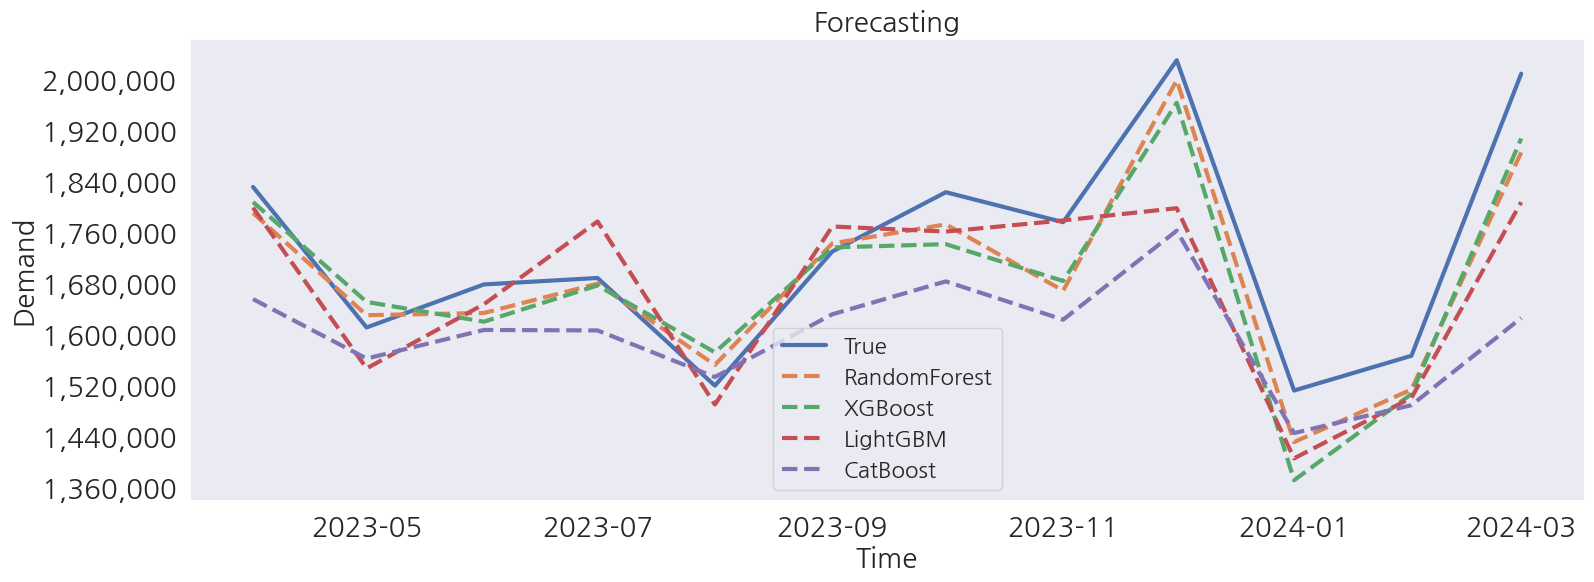

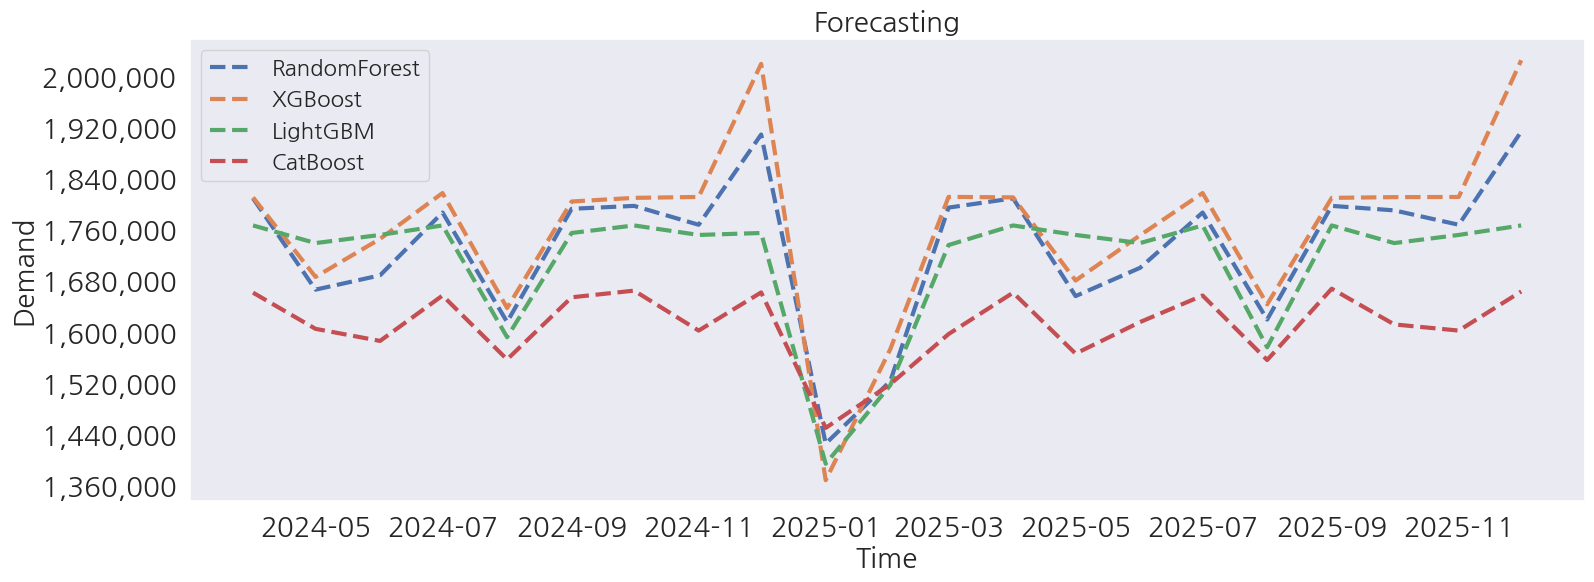

In [40]:
# 예측치 시각화
### Date and Author: 20240610, Kyungwon Kim ###
### Prediction plot
def evaluation_reg_PredPlot_DF(df_Ypred, title='Forecasting', xlabel='Index', ylabel='Y'):
    ## y 여부에 따른 중앙값만 별도 추출
    df_Ypred = df_Ypred[[col for col in df_Ypred.columns if col.split('-')[-1].isalpha()]]
    ## y가 있으면 시각화 추가하고 아니면 빼고 진행
    plt.figure(figsize=(18,6))
    if df_Ypred.columns.str.contains('y').sum() != 0:
        plt.plot(df_Ypred.index, df_Ypred['y'], linewidth=3)
    for col in df_Ypred.columns:
        if col != 'y':
            plt.plot(df_Ypred.index, df_Ypred[col], linestyle='--', linewidth=3)
    plt.ticklabel_format(axis='y', style='plain')
    plt.title(title, fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.legend([col if col != 'y' else 'True' for col in df_Ypred.columns], fontsize=16, loc='best')
    ## 쉼표 포멧 적용
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower'))  # 정수만 표시
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # 쉼표 추가
    plt.grid()
    plt.show()

## 알고리즘별 검증 및 예측기간 수요예측값
evaluation_reg_PredPlot_DF(Y_valpred, xlabel='Time', ylabel='Demand')
evaluation_reg_PredPlot_DF(Y_tepred.loc[:,[col for col in Y_tepred.columns if col != 'y']],
                           xlabel='Time', ylabel='Demand')

In [41]:
# 예측치 성능평가
### Date and Author: 20240620, Kyungwon Kim ###
### Evaluation of each pairs
def evaluation_reg_Metrics_DF(df_Ypred, ranking_metric=['MAPE']):
    # 정리
    df_Ypred = df_Ypred[[col for col in df_Ypred.columns if col.split('-')[-1].isalpha()]]

    # 평가
    Scores = pd.DataFrame()
    for i, col in enumerate(df_Ypred.columns):
        if col != 'y':
            # evaluator
            MSE = metrics.mean_squared_error(df_Ypred.y, df_Ypred[col])
            RMSE = np.sqrt(metrics.mean_squared_error(df_Ypred.y, df_Ypred[col]))
            MSPE = mean_squared_percentage_error(df_Ypred.y, df_Ypred[col])
            MAE = metrics.mean_absolute_error(df_Ypred.y, df_Ypred[col])
            MAPE = metrics.mean_absolute_percentage_error(df_Ypred.y, df_Ypred[col])
            MdAE = metrics.median_absolute_error(df_Ypred.y, df_Ypred[col])
            MdAPE = median_absolute_percentage_error(df_Ypred.y, df_Ypred[col])
            Score = pd.DataFrame([MSE, RMSE, MSPE, MAE, MAPE, MdAE, MdAPE],
                                 index=['MSE', 'RMSE', 'MSPE', 'MAE', 'MAPE', 'MedAE', 'MedAPE'], columns=['Score']).T
            Scores = pd.concat([Scores, Score], axis=0)
    Scores.index = df_Ypred.columns[1:]

    # 정렬
    if ranking_metric != None:
        Scores_sum = pd.DataFrame()
        for metric in ranking_metric:
            Scores_sum = pd.concat([Scores_sum, Scores[metric]], axis=1)
        Scores_ranking = Scores_sum.sum(axis=1).rank().sort_values().index
        Scores = Scores.loc[Scores_ranking,:]

    return Scores

scores = evaluation_reg_Metrics_DF(Y_valpred.iloc[:,1:], ranking_metric=RANKING_METRIC)
scores

,MSE,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE
RandomForest,3.755818e+09,61284.731837,0.001196,50489.996667,0.028954,42875.275000,0.024524
XGBoost,5.166892e+09,71881.092924,0.001813,61365.261719,0.035800,59257.875000,0.034651
LightGBM,1.088575e+10,104334.776502,0.003080,79723.669053,0.044479,63059.146672,0.036906
CatBoost,2.729229e+10,165203.789859,0.007434,131634.711440,0.071918,90418.827827,0.053229


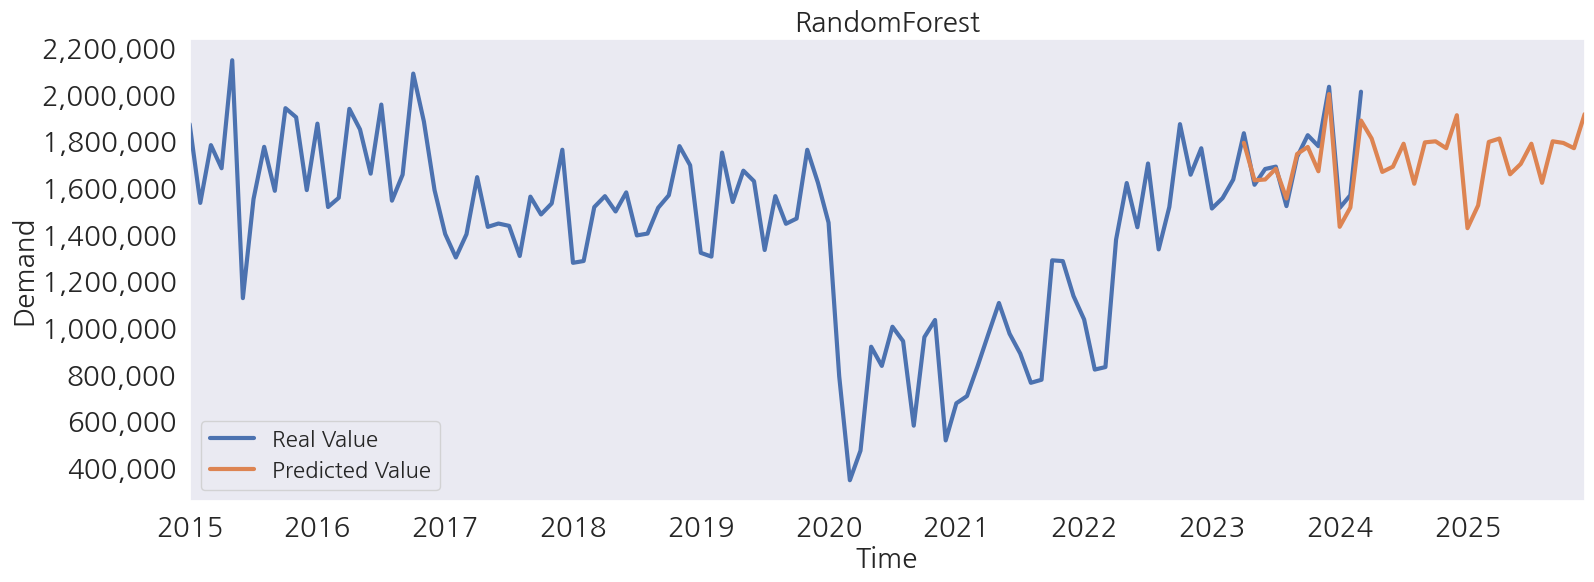

In [45]:
## 최종 미래 수요 예측
### Date and Author: 20240619, Kyungwon Kim ###
### Prediction plot
def evaluation_time_PredPlot(Y_real, Y_pred, Y_pred_index=False,
                             title='Algorithm', xlabel='Sequence', ylabel='Price',
                             visual_package='plotly', slider=True):
    # 데이터 정리
    if Y_pred_index:
        df_Y = pd.concat([Y_real, Y_pred], axis=1)
    else:
        df_Y = pd.concat([Y_real, pd.DataFrame(Y_pred,
                                               index=Y_real.index)], axis=1)
    df_Y.columns = ['Real Value', 'Predicted Value']

    # 시각화
    df_Y.plot(kind='line', figsize=(18,6), linewidth=3, fontsize=20,
              xlim=(df_Y.index.min(),df_Y.index.max()))
    plt.ticklabel_format(axis='y', style='plain')
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.legend(fontsize=16)
    ## 쉼표 포멧 적용
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower'))  # 정수만 표시
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # 쉼표 추가
    plt.grid()
    plt.show()

evaluation_time_PredPlot(pd.concat([df_train[Y_colname], df_validate[Y_colname]], axis=0),
                                    pd.concat([Y_valpred['RandomForest'], Y_tepred['RandomForest']], axis=0),
                                    Y_pred_index=True,
                                    title='RandomForest', xlabel='Time', ylabel='Demand', visual_package='matolotlib')

### ML Modeling Summary

In [4]:
### Date and Author: 20240531, Kyungwon Kim ###
### input change by nixtra package
def preprocessing_df2Nixtra(df, Y_colname, X_colname=None, time_colname=None):
    # nixtla 형태반영
    df_nixtra = pd.DataFrame()
    if time_colname == None:
        df_nixtra['ds'] = df.index
        df_nixtra['y'] = df[Y_colname].reset_index().iloc[:,1:].copy()
    else:
        df_nixtra['ds'] = df[time_colname].copy()
        df_nixtra['y'] = df[Y_colname].copy()

    # ID 설정
    df_nixtra['unique_id'] = 1.0

    # 정리
    df_nixtra = df_nixtra[['unique_id', 'ds', 'y']]

    # X 반영
    if X_colname != None:
        df_nixtra = pd.concat([df_nixtra, df[X_colname].reset_index().iloc[:,1:]], axis=1)

    return df_nixtra

### Date and Author: 20240620, Kyungwon Kim ###
### Evaluation of each pairs
def evaluation_reg_Metrics_DF(df_Ypred, ranking_metric=['MAPE']):
    # 정리
    df_Ypred = df_Ypred[[col for col in df_Ypred.columns if col.split('-')[-1].isalpha()]]

    # 평가
    Scores = pd.DataFrame()
    for i, col in enumerate(df_Ypred.columns):
        if col != 'y':
            # evaluator
            MSE = metrics.mean_squared_error(df_Ypred.y, df_Ypred[col])
            RMSE = np.sqrt(metrics.mean_squared_error(df_Ypred.y, df_Ypred[col]))
            MSPE = mean_squared_percentage_error(df_Ypred.y, df_Ypred[col])
            MAE = metrics.mean_absolute_error(df_Ypred.y, df_Ypred[col])
            MAPE = metrics.mean_absolute_percentage_error(df_Ypred.y, df_Ypred[col])
            MdAE = metrics.median_absolute_error(df_Ypred.y, df_Ypred[col])
            MdAPE = median_absolute_percentage_error(df_Ypred.y, df_Ypred[col])
            Score = pd.DataFrame([MSE, RMSE, MSPE, MAE, MAPE, MdAE, MdAPE],
                                 index=['MSE', 'RMSE', 'MSPE', 'MAE', 'MAPE', 'MedAE', 'MedAPE'], columns=['Score']).T
            Scores = pd.concat([Scores, Score], axis=0)
    Scores.index = df_Ypred.columns[1:]

    # 정렬
    if ranking_metric != None:
        Scores_sum = pd.DataFrame()
        for metric in ranking_metric:
            Scores_sum = pd.concat([Scores_sum, Scores[metric]], axis=1)
        Scores_ranking = Scores_sum.sum(axis=1).rank().sort_values().index
        Scores = Scores.loc[Scores_ranking,:]

    return Scores

### Date and Author: 20240610, Kyungwon Kim ###
### Prediction plot
def evaluation_reg_PredPlot_DF(df_Ypred, title='Forecasting', xlabel='Index', ylabel='Y'):
    ## y 여부에 따른 중앙값만 별도 추출
    df_Ypred = df_Ypred[[col for col in df_Ypred.columns if col.split('-')[-1].isalpha()]]
    ## y가 있으면 시각화 추가하고 아니면 빼고 진행
    plt.figure(figsize=(18,6))
    if df_Ypred.columns.str.contains('y').sum() != 0:
        plt.plot(df_Ypred.index, df_Ypred['y'], linewidth=3)
    for col in df_Ypred.columns:
        if col != 'y':
            plt.plot(df_Ypred.index, df_Ypred[col], linestyle='--', linewidth=3)
    plt.ticklabel_format(axis='y', style='plain')
    plt.title(title, fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.legend([col if col != 'y' else 'True' for col in df_Ypred.columns], fontsize=16, loc='best')
    ## 쉼표 포멧 적용
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower'))  # 정수만 표시
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # 쉼표 추가
    plt.grid()
    plt.show()

### Date and Author: 20240619, Kyungwon Kim ###
### Prediction plot
def evaluation_time_PredPlot(Y_real, Y_pred, Y_pred_index=False,
                             title='Algorithm', xlabel='Sequence', ylabel='Price',
                             visual_package='plotly', slider=True):
    # 데이터 정리
    if Y_pred_index:
        df_Y = pd.concat([Y_real, Y_pred], axis=1)
    else:
        df_Y = pd.concat([Y_real, pd.DataFrame(Y_pred,
                                               index=Y_real.index)], axis=1)
    df_Y.columns = ['Real Value', 'Predicted Value']

    # 시각화
    df_Y.plot(kind='line', figsize=(18,6), linewidth=3, fontsize=20,
              xlim=(df_Y.index.min(),df_Y.index.max()))
    plt.ticklabel_format(axis='y', style='plain')
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=20)
    plt.ylabel(ylabel, fontsize=20)
    plt.legend(fontsize=16)
    ## 쉼표 포멧 적용
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, prune='lower'))  # 정수만 표시
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))  # 쉼표 추가
    plt.grid()
    plt.show()

,MSE,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE
RandomForest,3.207991e+09,56639.133135,0.001052,47968.662500,0.027616,38750.780000,0.020721
XGBoost,5.166892e+09,71881.092924,0.001813,61365.261719,0.035800,59257.875000,0.034651
LightGBM,1.088575e+10,104334.776502,0.003080,79723.669053,0.044479,63059.146672,0.036906
CatBoost,2.729229e+10,165203.789859,0.007434,131634.711440,0.071918,90418.827827,0.053229


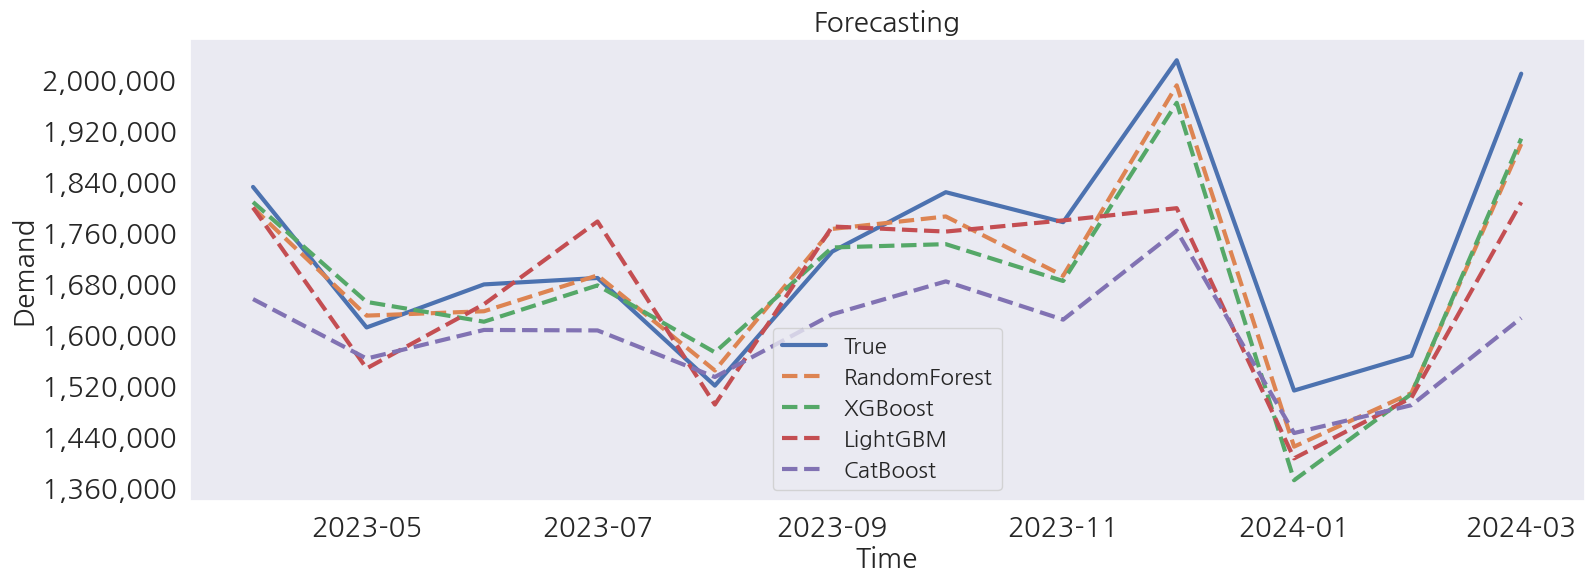

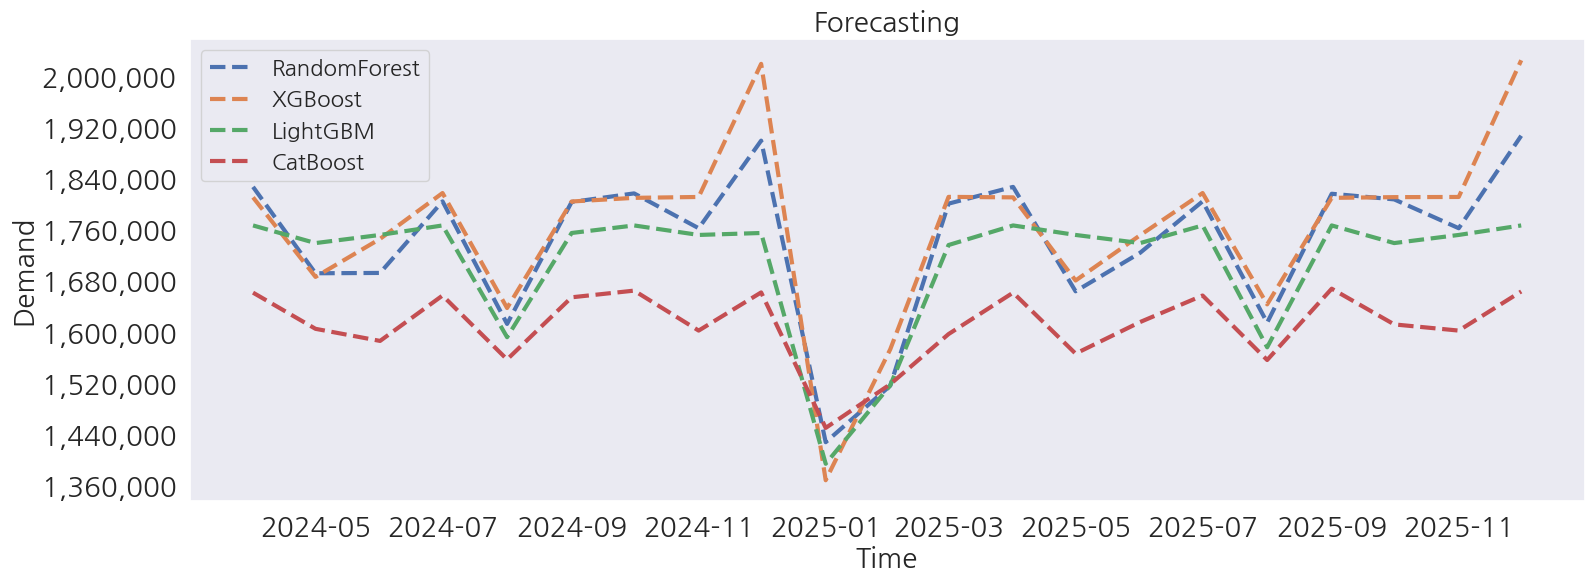

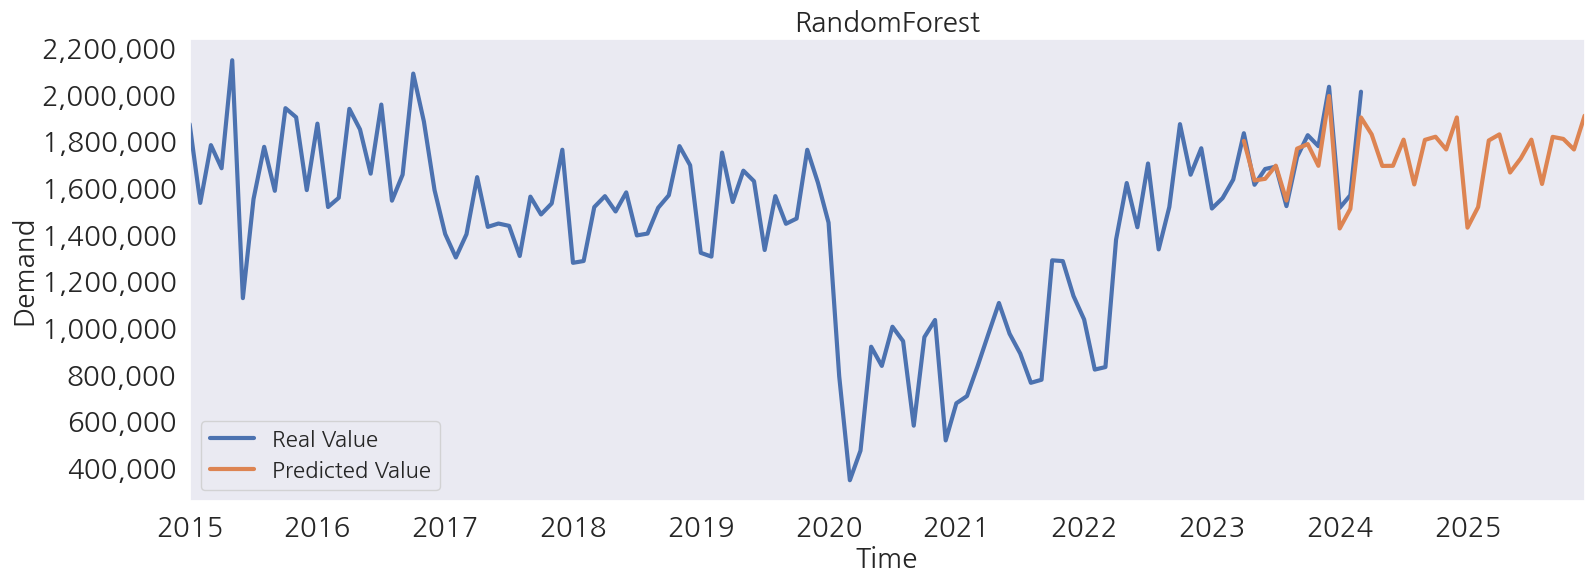

In [5]:
# 시계열 분석을 위한 형태 변환
nf_train = preprocessing_df2Nixtra(df_train, Y_colname, X_colname=X_colname)
nf_test = preprocessing_df2Nixtra(pd.concat([df_validate, df_test], axis=0),
                                  Y_colname, X_colname=X_col_FUTR)

# 대상 모델 정리
models = {'RandomForest': RandomForestRegressor(verbose=0),
          'XGBoost': XGBRegressor(verbose=-1),
          'LightGBM': LGBMRegressor(verbose=-1),
          'CatBoost': CatBoostRegressor(silent=True)}

# 모델 반영 및 학습
model = MLForecast(models=models, freq=df_train.index.inferred_freq)
model.fit(df=nf_train[list(nf_train.columns[:3])+X_col_FUTR],
          static_features=X_col_STATIC_ML)

# 예측
Y_pred = model.predict(h=nf_test.shape[0], X_df=nf_test[[col for col in nf_test.columns if col != 'y']])
Y_pred_ML = pd.merge(nf_test.iloc[:,:3], Y_pred, how='left', on=['unique_id', 'ds'])
Y_pred_ML.set_index('ds', inplace=True)
Y_pred_ML.index = pd.to_datetime(Y_pred_ML.index)

# 예측치 성능평가
## Validate & Test 분리
Y_valpred, Y_tepred = Y_pred_ML.iloc[:df_validate.shape[0],:], Y_pred_ML.iloc[df_validate.shape[0]:,:]
scores = evaluation_reg_Metrics_DF(Y_valpred.iloc[:,1:], ranking_metric=RANKING_METRIC)
display(scores)

## 알고리즘별 검증 및 예측기간 수요예측값
evaluation_reg_PredPlot_DF(Y_valpred, xlabel='Time', ylabel='Demand')
evaluation_reg_PredPlot_DF(Y_tepred.loc[:,[col for col in Y_tepred.columns if col != 'y']],
                           xlabel='Time', ylabel='Demand')

## 최종 미래 수요 예측
evaluation_time_PredPlot(pd.concat([df_train[Y_colname], df_validate[Y_colname]], axis=0),
                                    pd.concat([Y_valpred['RandomForest'], Y_tepred['RandomForest']], axis=0),
                                    Y_pred_index=True,
                                    title='RandomForest', xlabel='Time', ylabel='Demand', visual_package='matolotlib')

## DL Forecast

### (1) Input Transformation

In [6]:
# 시계열 분석을 위한 형태 변환
nf_train = preprocessing_df2Nixtra(df_train, Y_colname, X_colname=X_colname)
nf_test = preprocessing_df2Nixtra(pd.concat([df_validate, df_test], axis=0),
                                  Y_colname, X_colname=X_col_FUTR)
display(nf_train.head(), nf_test.head())

,unique_id,ds,y,일수,주말수,주중수,공휴일수,명절수,공급차량수,공급좌석합계수,...,조사망률(천명당),자연증가율(천명당),합계출산율(명),출생성비(명),혼인건수(건),조혼인율(천명당),이혼건수(건),조이혼율(천명당),News_Count,Sentiment
0,1.0,2015-01-01,1871129,14,14,0,0,0,34020,1741181,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,74.0,-18.0
1,1.0,2015-02-01,1533571,12,12,0,1,1,28992,1488544,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,118.0,-84.0
2,1.0,2015-03-01,1780862,13,13,0,1,0,31246,1607627,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,76.0,10.0
3,1.0,2015-04-01,1681821,12,12,0,0,0,28848,1491483,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,80.0,-20.0
4,1.0,2015-05-01,2144330,15,15,0,0,0,36102,1863967,...,5.4,3.2,1.239,105.3,302828.0,5.9,109153.0,2.1,73.0,-27.0


,unique_id,ds,y,일수,주말수,주중수,공휴일수,명절수,공급좌석합계수,승차율,...,자연증가건수(명),조출생률(천명당),조사망률(천명당),자연증가율(천명당),합계출산율(명),출생성비(명),혼인건수(건),조혼인율(천명당),이혼건수(건),조이혼율(천명당)
0,1.0,2023-04-01,1831775,14,14,0,0,0,1576024,9.745437,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8
1,1.0,2023-05-01,1611120,12,12,0,2,0,1350332,8.656264,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8
2,1.0,2023-06-01,1678704,13,13,0,0,0,1462285,8.954923,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8
3,1.0,2023-07-01,1688805,14,14,0,0,0,1553104,9.269145,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8
4,1.0,2023-08-01,1519750,12,12,0,0,0,1350332,8.377445,...,-122483.0,4.5,6.9,-2.4,0.721,105.1,193657.0,3.8,92394.0,1.8


### (2) Learning and Forecasting

In [7]:
# 대상 모델 정리
# models = [MLP, NBEATS, NHITS, NBEATSx, TiDE, RNN, LSTM, GRU, DilatedRNN, TCN]
models = [RNN, LSTM, GRU, DilatedRNN, TCN]
config = {'input_size':nf_test.shape[0]*2, 'h':nf_test.shape[0],
          'futr_exog_list':X_col_FUTR,
          'hist_exog_list':[col for col in df_train.columns if col not in [Y_colname]+X_col_FUTR],
          'stat_exog_list':X_col_STATIC_DL,
          'enable_checkpointing':False, 'logger':False}
models = [algo(**config) for algo in models]

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


In [8]:
# 모델 반영 및 학습
model = NeuralForecast(models=models, freq=df_train.index.inferred_freq)
model.fit(df=nf_train)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | RNN           | 63.9 K | train
4 | mlp_decoder  | MLP           | 20.2 K | train
-------------------------------------------------------
84.1 K    Trainable params
0         Non-trainable params
84.1 K    Total params
0.336     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [11]:
# 예측
Y_pred = model.predict(futr_df=nf_test.reset_index())
Y_pred_DL = pd.merge(nf_test.iloc[:,:3], Y_pred, how='left', on=['unique_id', 'ds'])
Y_pred_DL.set_index('ds', inplace=True)
Y_pred_DL.index = pd.to_datetime(Y_pred_DL.index)
Y_pred_DL

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,y,RNN,LSTM,GRU,DilatedRNN,TCN
ds,,,,,,,
2023-04-01,1.0,1831775,1736334.625,1732735.375,1681038.125,1808535.875,1720780.750
2023-05-01,1.0,1611120,1536006.250,1600901.500,1550859.750,1518182.125,1457916.250
2023-06-01,1.0,1678704,1647247.375,1654075.500,1613619.500,1703521.000,1539841.000
2023-07-01,1.0,1688805,1725753.125,1717866.625,1667425.500,1770153.125,1580382.500
2023-08-01,1.0,1519750,1554417.250,1593497.625,1548983.625,1627531.250,1482844.875
2023-09-01,1.0,1730278,1614363.375,1659161.250,1566829.250,1750155.125,1657967.375
2023-10-01,1.0,1823506,1568567.625,1685326.625,1623265.625,1750040.875,1767661.250
2023-11-01,1.0,1776440,1264841.375,1605968.375,1559457.000,1653929.750,1678418.375
2023-12-01,1.0,2030693,1247360.500,1798872.625,1746464.625,1933577.000,1766743.750


### (3) Performance Evaluation

,MSE,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE
DilatedRNN,5.457405e+09,73874.254243,0.001897,65043.375000,0.038172,70731.2500,0.041845
LSTM,1.575652e+10,125524.983457,0.004466,101232.789062,0.055911,84001.5625,0.051297
TCN,1.767865e+10,132961.089767,0.005267,114135.851562,0.063940,109708.3750,0.062397
GRU,4.423048e+10,210310.446645,0.013327,166336.015625,0.092520,157092.8125,0.088377
RNN,2.487616e+11,498760.060502,0.082754,363272.906250,0.207496,185426.5000,0.103399


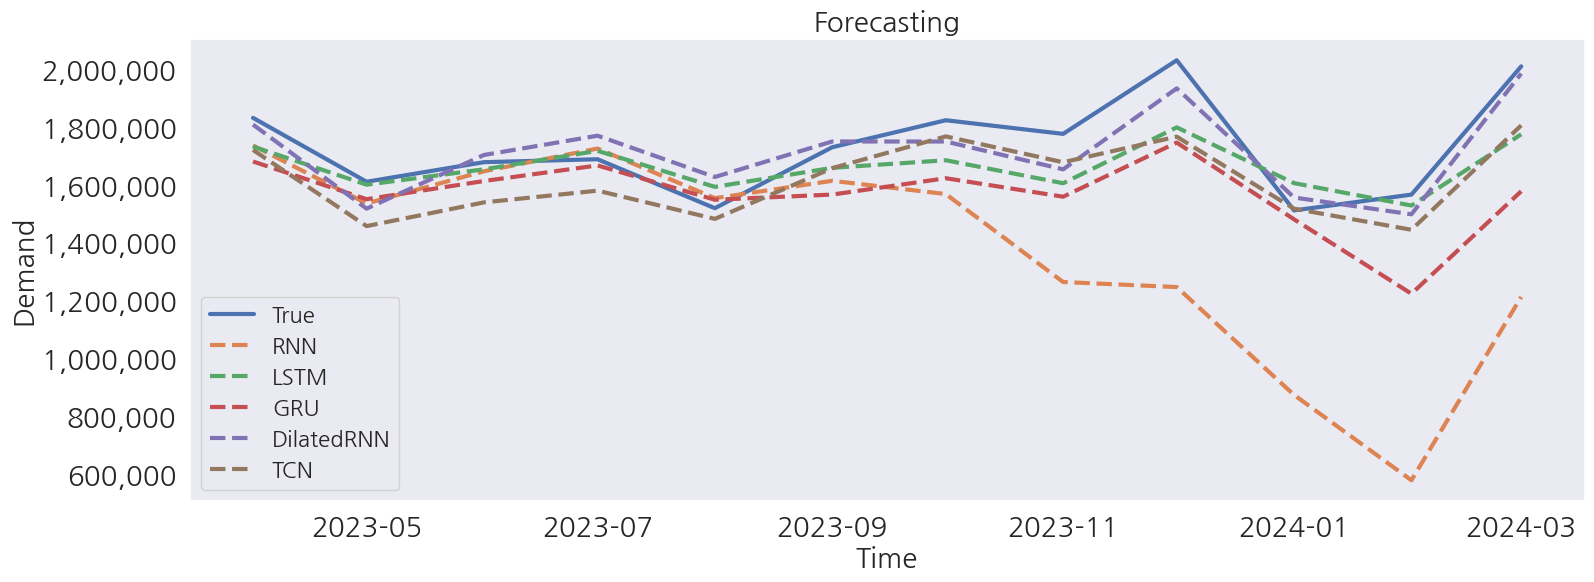

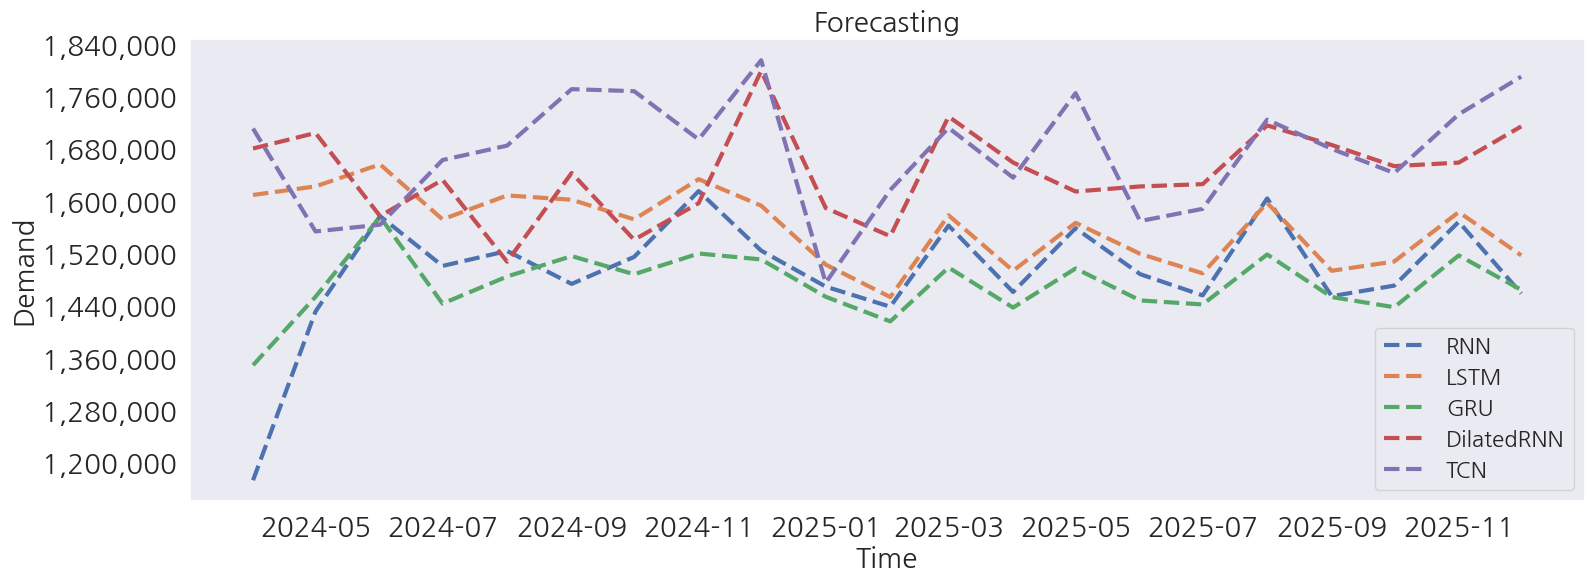

In [12]:
# 예측치 성능평가
## Validate & Test 분리
Y_valpred, Y_tepred = Y_pred_DL.iloc[:df_validate.shape[0],:], Y_pred_DL.iloc[df_validate.shape[0]:,:]
scores = evaluation_reg_Metrics_DF(Y_valpred.iloc[:,1:], ranking_metric=RANKING_METRIC)
display(scores)

## 알고리즘별 검증 및 예측기간 수요예측값
evaluation_reg_PredPlot_DF(Y_valpred, xlabel='Time', ylabel='Demand')
evaluation_reg_PredPlot_DF(Y_tepred.loc[:,[col for col in Y_tepred.columns if col != 'y']],
                           xlabel='Time', ylabel='Demand')

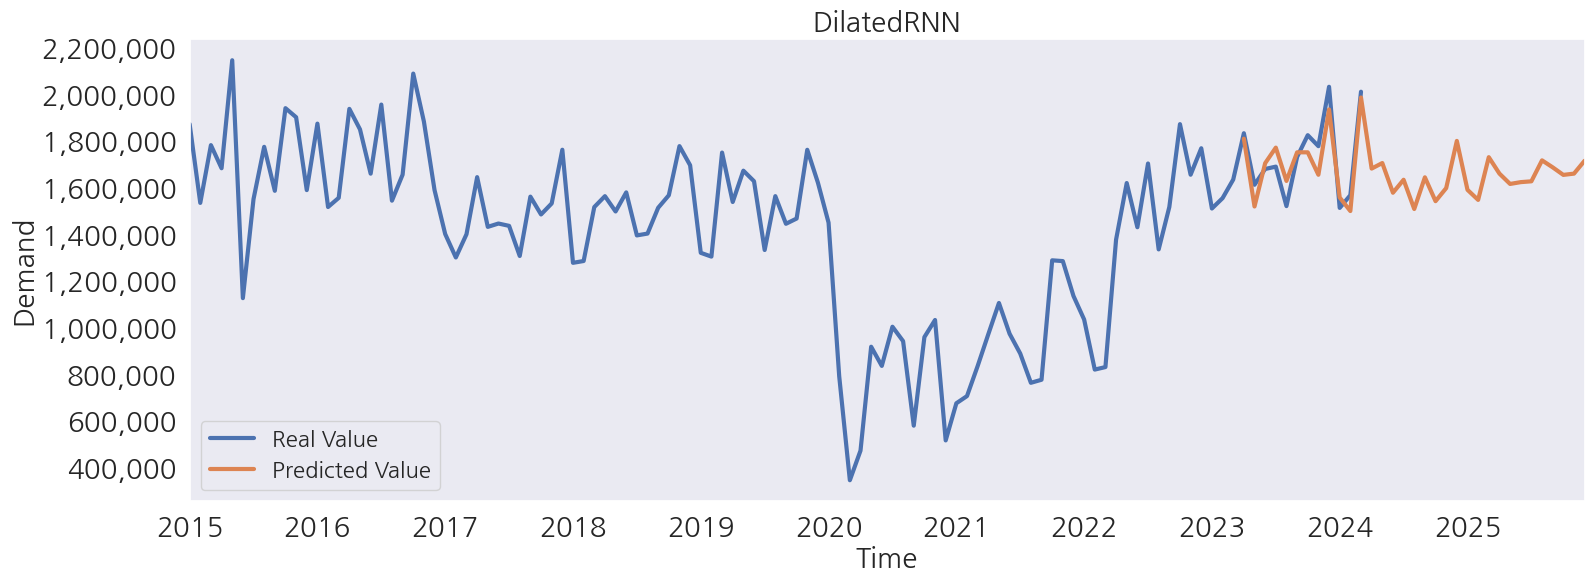

In [14]:
## 최종 미래 수요 예측
evaluation_time_PredPlot(pd.concat([df_train[Y_colname], df_validate[Y_colname]], axis=0),
                                    pd.concat([Y_valpred['DilatedRNN'], Y_tepred['DilatedRNN']], axis=0),
                                    Y_pred_index=True,
                                    title='DilatedRNN', xlabel='Time', ylabel='Demand', visual_package='matolotlib')

### DL Modeling Summary

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | RNN           | 63.9 K | train
4 | mlp_decoder  | MLP           | 20.2 K | train
-------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

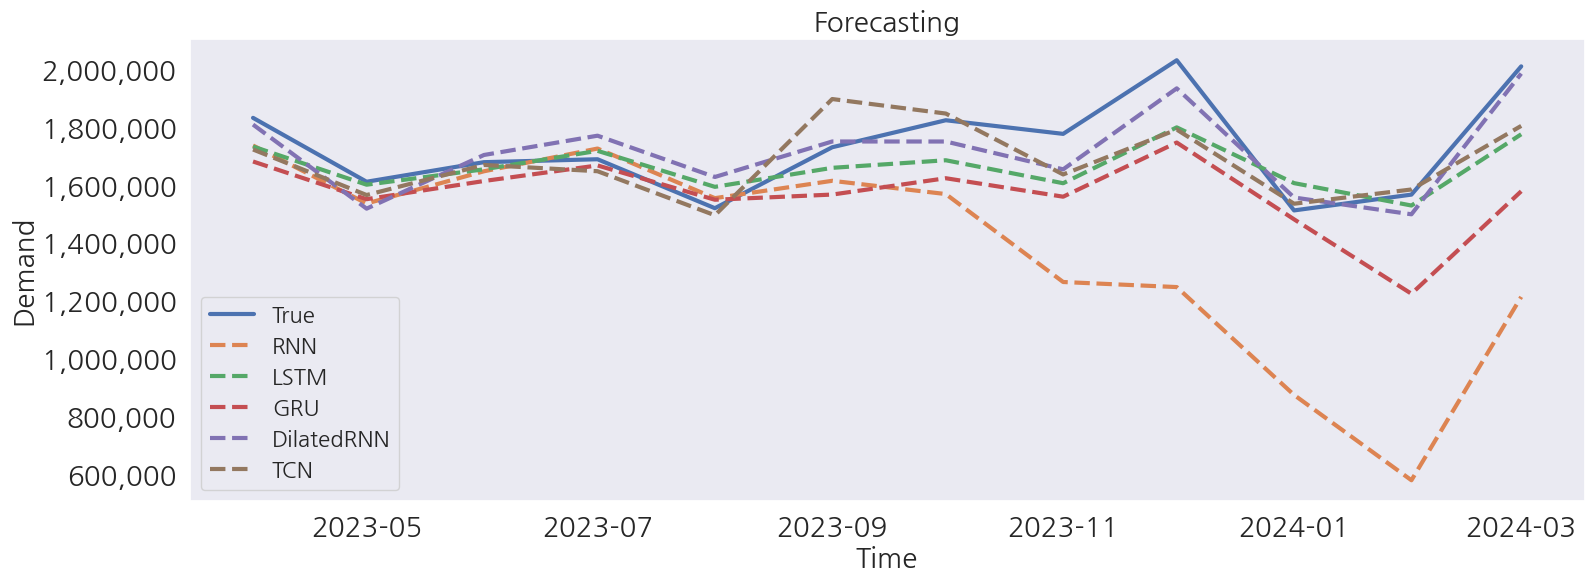

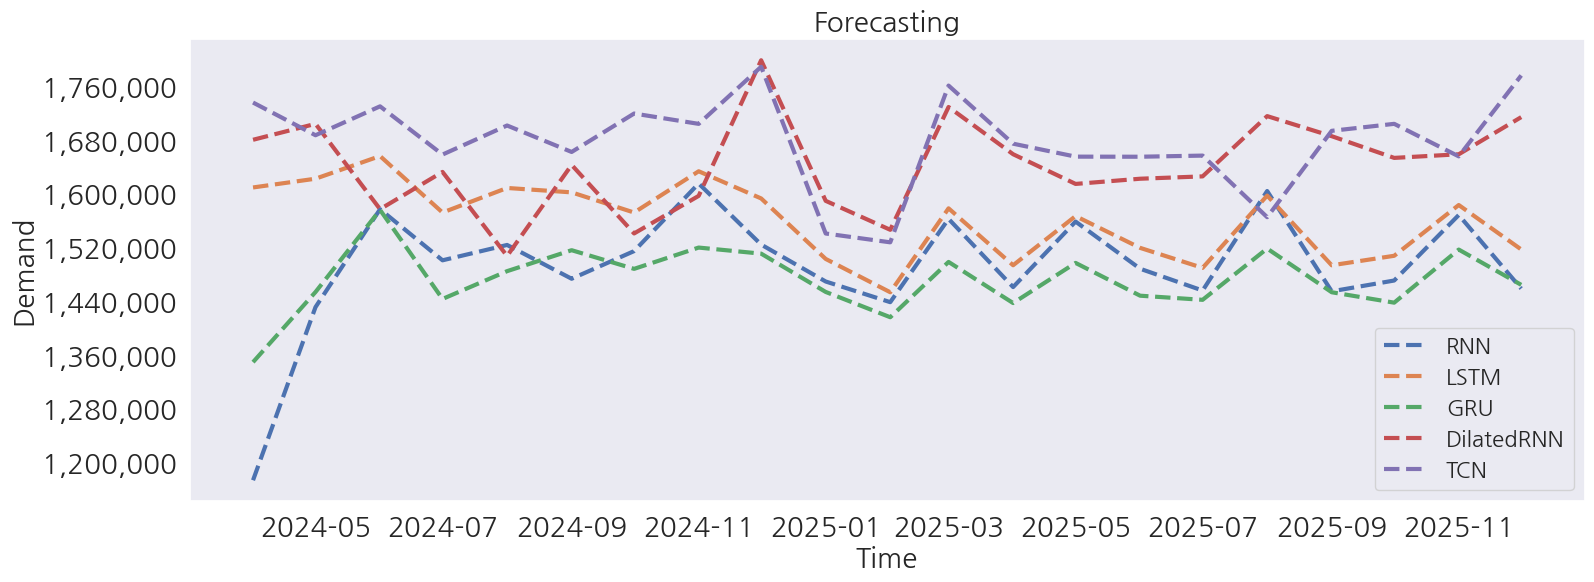

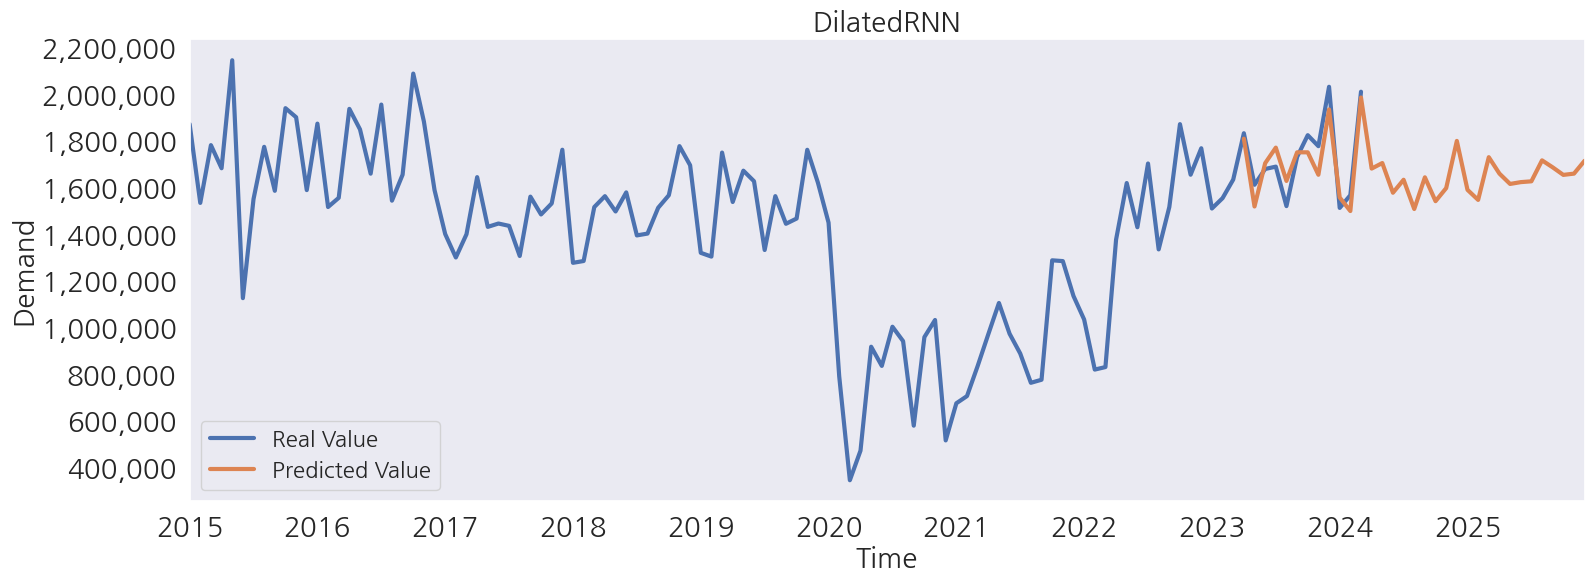

In [15]:
# 시계열 분석을 위한 형태 변환
nf_train = preprocessing_df2Nixtra(df_train, Y_colname, X_colname=X_colname)
nf_test = preprocessing_df2Nixtra(pd.concat([df_validate, df_test], axis=0),
                                  Y_colname, X_colname=X_col_FUTR)

# 대상 모델 정리
# models = [MLP, NBEATS, NHITS, NBEATSx, TiDE, RNN, LSTM, GRU, DilatedRNN, TCN]
models = [RNN, LSTM, GRU, DilatedRNN, TCN]
config = {'input_size':nf_test.shape[0]*2, 'h':nf_test.shape[0],
          'futr_exog_list':X_col_FUTR,
          'hist_exog_list':[col for col in df_train.columns if col not in [Y_colname]+X_col_FUTR],
          'stat_exog_list':X_col_STATIC_DL,
          'enable_checkpointing':False, 'logger':False}
models = [algo(**config) for algo in models]

# 모델 반영 및 학습
model = NeuralForecast(models=models, freq=df_train.index.inferred_freq)
model.fit(df=nf_train)

# 예측
Y_pred = model.predict(futr_df=nf_test.reset_index())
Y_pred_DL = pd.merge(nf_test.iloc[:,:3], Y_pred, how='left', on=['unique_id', 'ds'])
Y_pred_DL.set_index('ds', inplace=True)
Y_pred_DL.index = pd.to_datetime(Y_pred_DL.index)

# 예측치 성능평가
## Validate & Test 분리
Y_valpred, Y_tepred = Y_pred_DL.iloc[:df_validate.shape[0],:], Y_pred_DL.iloc[df_validate.shape[0]:,:]
scores = evaluation_reg_Metrics_DF(Y_valpred.iloc[:,1:], ranking_metric=RANKING_METRIC)

## 알고리즘별 검증 및 예측기간 수요예측값
evaluation_reg_PredPlot_DF(Y_valpred, xlabel='Time', ylabel='Demand')
evaluation_reg_PredPlot_DF(Y_tepred.loc[:,[col for col in Y_tepred.columns if col != 'y']],
                           xlabel='Time', ylabel='Demand')

## 최종 미래 수요 예측
evaluation_time_PredPlot(pd.concat([df_train[Y_colname], df_validate[Y_colname]], axis=0),
                                    pd.concat([Y_valpred['DilatedRNN'], Y_tepred['DilatedRNN']], axis=0),
                                    Y_pred_index=True,
                                    title='DilatedRNN', xlabel='Time', ylabel='Demand', visual_package='matolotlib')

# BA Process Summary

## 1) Library

In [16]:
# Auto reload of library
%load_ext autoreload
%autoreload 2

# System related and data input controls
import os

# Ignore the warnings
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Visualization
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
## 한글 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum* -qq
## NanumGothic 폰트 경로 지정
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
## 한글 폰트 설정
matplotlib.rcParams['font.family'] = font_prop.get_name()
plt.rc('font', family='NanumGothic')
sns.set(font=font_prop.get_name())
## 마이너스 표시 설정
plt.rcParams['axes.unicode_minus'] = False

# Custom
## 사용자의 실제 작업경로로 설정!
work_path = '/content/drive/MyDrive/Research/Analysis/Lecture/특강_20250412_한국지능정보사회진흥원_빅데이터센터'
os.chdir(work_path)
!ls
from module_KK import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 BA1_TargetMarketing_DataPrepModelingBase_KK.ipynb
 BA1_TargetMarketing_ModelingAI_KK.ipynb
 BA2_DemandForecasting_DataPreprocessing_KK.ipynb
 BA2_DemandForecasting_DataSentiment_KK.ipynb
 BA2_DemandForecasting_ModelingAI_KK.ipynb
 BA2_Practice.ipynb
 catboost_info
 Data
 Image
 Lecture2-0_DataAnalysis_RealDataAnalysis_KK.ipynb
 Lecture2-1_DataAnalysis_LearningAlgorithm_KK.ipynb
 Lecture2-2_DataAnalysis_SupervisedRegression_KK.ipynb
 Lecture2-3_DataAnalysis_SupervisedClassification_KK.ipynb
 Lecture3-1_MachineLearning_SupervisedEvolutionSummary_KK.ipynb
 Lecture4-1_DeepLearning_HistoryAI_KK.ipynb
 Lecture4-2_DeepLearning_AdvancedAI_KK.ipynb
 Lecture4-3_DeepLearning_BaseAlgorithms_KK.ipynb
 mlruns
 Model
 model.png

## 2) Hyperparameter

In [17]:
# Data Preprocessing
folder_location = os.path.join(os.path.join('.', 'Data'))
Y_colname = '승차인원수'
RANDOM_STATE = 123
DATE_SPLITS = ['2023-03-31', '2024-03-31']
X_col_FUTR = ['일수', '주말수', '주중수', '공휴일수', '명절수',
              '공급좌석합계수', '승차율', '열차운행횟수',
              ## 미래는 코로나가 없다는 가정
              '사망자수', '접종시작자수', '격리된자수', '정부대응정도',
              '확진자수', '접종완료자수', '코로나진행정도', '국가이동제한정도',
              ## 인구정보는 현재와 변함이 없다는 가정
              '출생아수(명)', '사망자수(명)', '자연증가건수(명)', '조출생률(천명당)', '조사망률(천명당)',
              '자연증가율(천명당)', '합계출산율(명)', '출생성비(명)',
              '혼인건수(건)', '조혼인율(천명당)', '이혼건수(건)', '조이혼율(천명당)']
X_col_STATIC_ML = []
X_col_STATIC_DL = None

# Modeling
N_WINDOWS = 2
RANDOM_STATE = 123
VERBOSITY = 0

# Evaluation
RANKING_METRIC = ['MSPE', 'MAPE', 'MedAPE']

## 3) Data Preprocessing

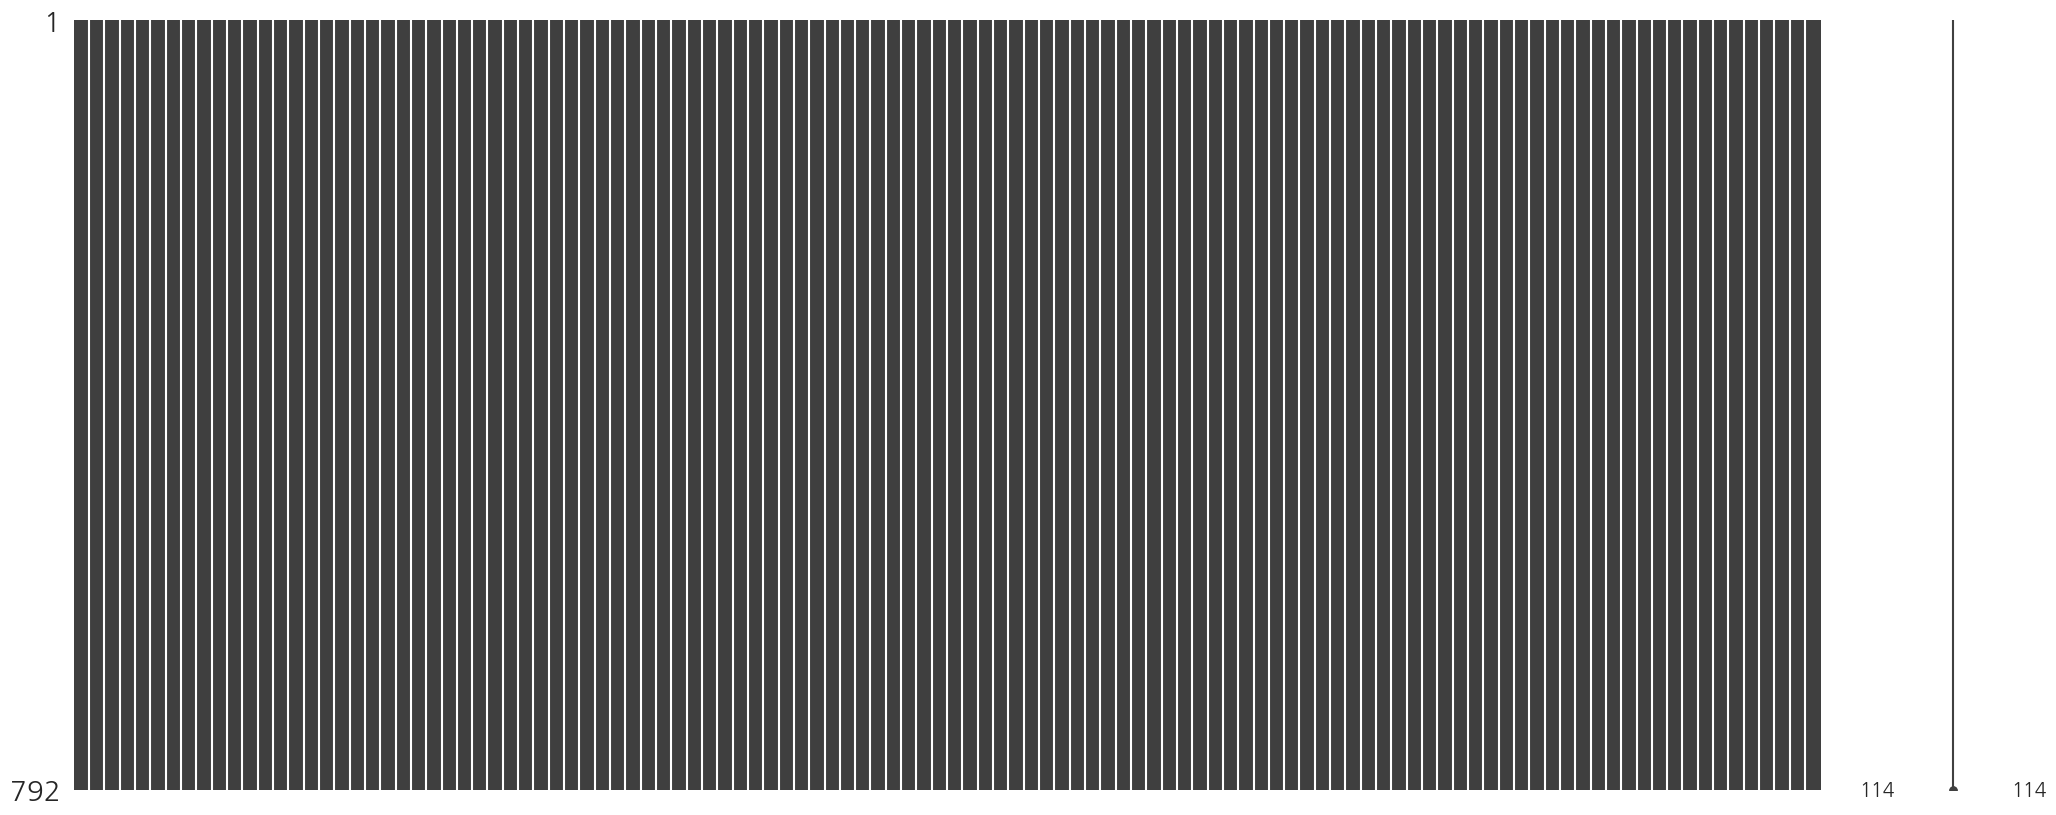

(99, 111) (12, 111) (21, 111)


In [18]:
# 데이터 준비
## 1) 비즈니스 데이터
df = pd.read_csv(os.path.join(folder_location, 'df_KTX_monthsum_example_KK.csv'), encoding='utf-8-sig')
df['Date'] = pd.to_datetime(df['Date'])
## 2) Econ 데이터
df_active = pd.read_excel(os.path.join(folder_location, 'ECON_경제활동인구_KK.xlsx'), sheet_name='데이터', header=7)
df_active['Date'] = pd.to_datetime(df_active['Date'])
df_sentiment = pd.read_excel(os.path.join(folder_location, 'ECON_소비자동향조사(전국, 월, 2008.9~)_KK.xlsx'), sheet_name='데이터', header=7)
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date'])
df_sentiment = df_sentiment.dropna(axis=1)
df_price = pd.read_excel(os.path.join(folder_location, 'ECON_소비자물가지수_KK.xlsx'), sheet_name='데이터', header=6)
df_price['Date'] = pd.to_datetime(df_price['Date'])
## 3) Kosis 데이터
df_traffic = pd.read_csv(os.path.join(folder_location, 'KOSIS_내국인출국교통수단별_KK.csv'), encoding='cp949', header=2)
df_traffic['Date'] = pd.to_datetime(df_traffic['Date'])
df_traffic['내국인출입국_공항'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '공항']].sum(axis=1).values
df_traffic['내국인출입국_항구'] = df_traffic[[col for col in df_traffic.columns if col.split('_')[0] == '항구']].sum(axis=1).values
df_traffic.drop(columns=[col for col in df_traffic.columns if col.split('_')[0] in ['공항', '항구']], inplace=True)
df_entry = pd.read_csv(os.path.join(folder_location, 'KOSIS_외래객_입국목적별_국적별_KK.csv'), encoding='cp949', header=1)
df_entry['Date'] = pd.to_datetime(df_entry['Date'])
df_population = pd.read_csv(os.path.join(folder_location, 'KOSIS_인구동태건수_및_동태율_추이_출생_사망_혼인_이혼__KK.csv'), encoding='cp949', header=0)
df_population['Date'] = pd.to_datetime(df_population['Date'], format='%Y', errors='coerce')
df_population = df_population[[col for col in df_population.columns if col not in ['영아사망률(출생아 천명당)', '기대수명(출생시 기대여명)',
                                                                                   '기대수명(출생시 기대여명) - 남', '기대수명(출생시 기대여명) - 여']]]
## 뉴스 데이터
df_news = pd.read_excel(os.path.join(folder_location, 'NewsResult_20150101-20250331_KTX코레일.xlsx'), header=0)
df_news.rename(columns={'일자':'Date'}, inplace=True)
df_news['Date'] = pd.to_datetime(df_news['Date'], format='%Y%m%d')
df_news = df_news[['Date', '언론사', '통합 분류1', '제목', '본문']]
df_news = df_news.sort_values(by='Date', ascending=True).reset_index().iloc[:,1:]
## 4) 뉴스 트래픽 추출
df_news['Date_Group'] = df_news['Date'].apply(lambda x: str(x)[:7])
df_news_count = df_news.groupby('Date_Group')['제목'].count().reset_index()
df_news_count.rename(columns={'제목':'News_Count'}, inplace=True)
df_news_count['Date'] = pd.to_datetime(df_news_count.Date_Group, format='%Y-%m', errors='coerce')
df_news_count = df_news_count[['Date', 'News_Count']]
## 5) 감성 추출 데이터 정리
df_news_sentiment = pd.read_csv(os.path.join('.', 'Data', 'NewsResult_20150101-20250331_KTX코레일_Sentiment.csv'),
                                encoding='utf-8-sig')
df_news_sentiment['Sentiment'] = df_news_sentiment['Sentiment'].apply(lambda x: -1 if x==0 else 1)
## 일 -> 월 감성 집계
df_news_sentiment = pd.concat([df_news.Date, df_news.Date_Group, df_news_sentiment['Sentiment']], axis=1)
df_news_sentiment = df_news_sentiment.groupby('Date_Group')['Sentiment'].sum().reset_index()
df_news_sentiment['Date_Group'] = pd.to_datetime(df_news_sentiment.Date_Group, format='%Y-%m')
df_news_sentiment.rename(columns={'Date_Group':'Date'}, inplace=True)

# 데이터 결합
df = pd.merge(df, df_active, on='Date', how='left').fillna(0)
df = pd.merge(df, df_sentiment, on='Date', how='left').fillna(0)
df = pd.merge(df, df_price, on='Date', how='left').fillna(0)
df = pd.merge(df, df_traffic, on='Date', how='left').fillna(0)
df = pd.merge(df, df_entry, on='Date', how='left').fillna(0)
df = pd.merge(df, df_population, on='Date', how='left').fillna(method='ffill')
df = pd.merge(df, df_news_count, on='Date', how='left').fillna(0)
df = pd.merge(df, df_news_sentiment, on='Date', how='left').fillna(0)
## 변수명 좌우공백 제거
df.columns = [col.strip() for col in df.columns]

# 데이터 전처리
# 1) 불필요 변수 삭제
## 결측치의 비율이 50% 넘는 변수 삭제
## 변수의 값 종류가 1개인 변수 삭제
## 분석과 무관한 변수 삭제

# 2) 결측치 채우기
msno.matrix(df)
plt.show()

# 3) 대상노선 결정
df = df[(df['주운행선'] == '경부선') & (df['전체주중주말'] == '주말')]
df.drop(columns=['주운행선', '전체주중주말'], inplace=True)

# 4) Train, Validate, Test 분리
## 시간인덱스 설정
if 'Date' in df.columns:
  df.set_index('Date', inplace=True)
if len(DATE_SPLITS) == 2:
  df_train = df[df.index <= DATE_SPLITS[0]]
  df_validate = df[(df.index > DATE_SPLITS[0]) & (df.index <= DATE_SPLITS[1])]
  df_test = df[(df.index > DATE_SPLITS[1])]
print(df_train.shape, df_validate.shape, df_test.shape)

# 5) Y & X 분리
X_colname = [col for col in df.columns if col not in [Y_colname]]

# 6) 스케일링
## 시계열 딥러닝 알고리즘 내 포함되어 생략

## 4) Modeling AI

| **모델링 종류** | **알고리즘 분야** | **이름** | **개발연도** |
|:---:|:---:|:---:|:---:|
| **Machine Learning** | **Bagging** | RandomForest | 2001 |
|  | **Boosting** | XGBoost | 2014 |
|  |  | LightGBM | 2016 |
|  |  | CatBoost | 2017 |
| **Deep Learning** | **MLP** | MLP | 2010 |
|  |  | NBEATS | 2019 |
|  |  | NHITS | 2021 |
|  |  | NBEATSx | 2021 |
|  |  | TiDE | 2023 |
|  |  | DeepNPTS | 2023 |
|  | **RNN** | RNN | 2014 |
|  |  | LSTM | 2014 |
|  |  | GRU | 2014 |
|  |  | DilatedRNN | 2017 |
|  |  | TCN | 2018 |
|  |  | DeepAR | 2020 |
|  | **Transformer** | Vanilla Transformer | 2021 |
|  |  | Informer | 2021 |
|  |  | TFT | 2021 |
|  |  | Autoformer | 2021 |
|  |  | PatchTST | 2022 |

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,MSE,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE
RandomForest,2.880134e+09,53666.876164,0.000930,44032.912500,0.025465,31301.800000,0.018818
XGBoost,5.166892e+09,71881.092924,0.001813,61365.261719,0.035800,59257.875000,0.034651
TCN,6.953572e+09,83388.079724,0.001953,68149.648438,0.037572,59844.687500,0.035631
DilatedRNN,5.457405e+09,73874.254243,0.001897,65043.375000,0.038172,70731.250000,0.041845
LightGBM,1.088575e+10,104334.776502,0.003080,79723.669053,0.044479,63059.146672,0.036906
LSTM,1.575652e+10,125524.983457,0.004466,101232.789062,0.055911,84001.562500,0.051297
CatBoost,2.729229e+10,165203.789859,0.007434,131634.711440,0.071918,90418.827827,0.053229
NHITS,4.486655e+10,211817.260411,0.016092,168085.765625,0.099643,135448.687500,0.071749
GRU,4.423048e+10,210310.446645,0.013327,166336.015625,0.092520,157092.812500,0.088377
TiDE,1.777315e+11,421582.160989,0.049051,315636.343750,0.174054,238229.750000,0.140128


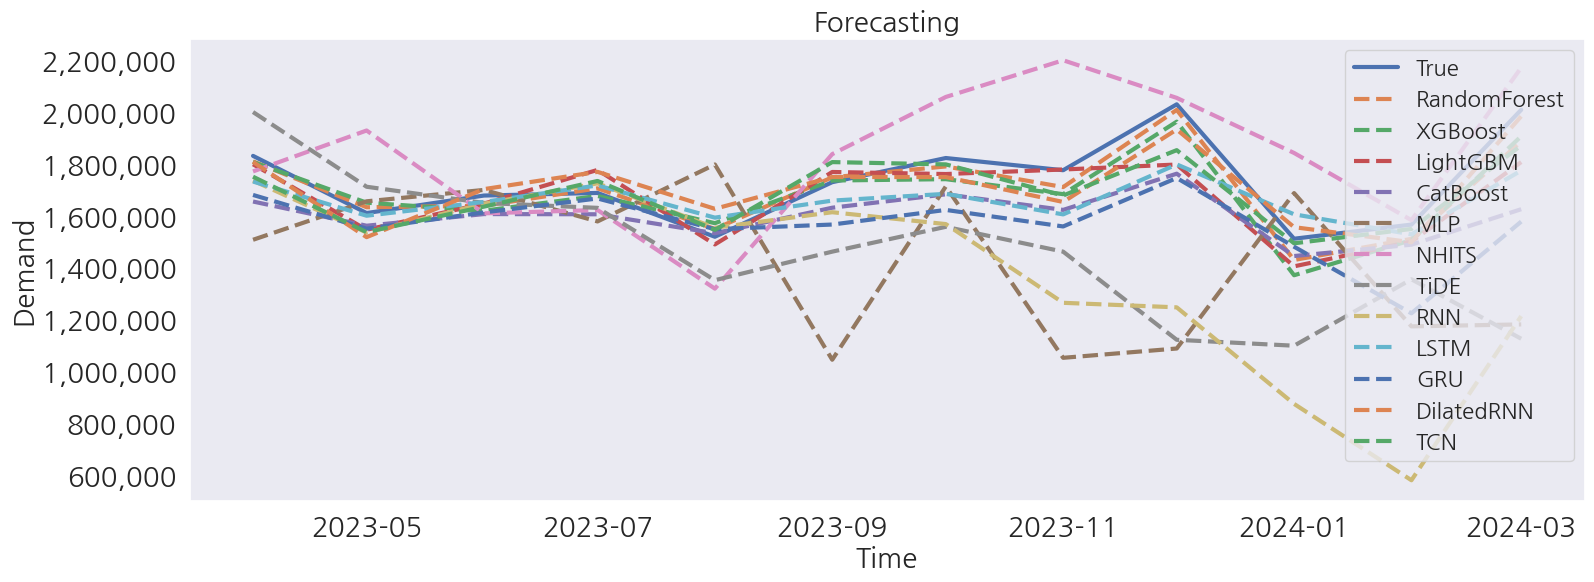

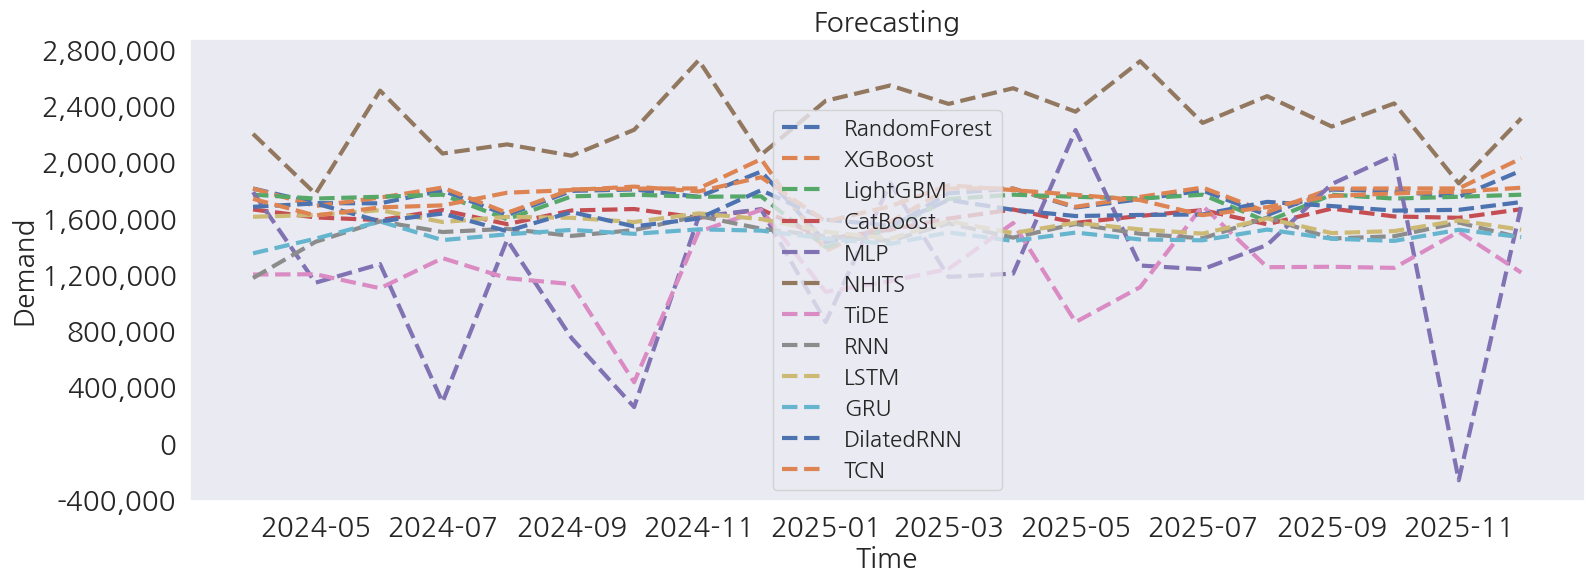

In [23]:
# 시계열 분석을 위한 형태 변환
nf_train = preprocessing_df2Nixtra(df_train, Y_colname, X_colname=X_colname)
nf_test = preprocessing_df2Nixtra(pd.concat([df_validate, df_test], axis=0),
                                  Y_colname, X_colname=X_col_FUTR)

# 모델 반영 및 학습
## Machine Learning
models = {'RandomForest': RandomForestRegressor(verbose=0),
          'XGBoost': XGBRegressor(verbose=-1),
          'LightGBM': LGBMRegressor(verbose=-1),
          'CatBoost': CatBoostRegressor(silent=True)}
model_ML = MLForecast(models=models, freq=df_train.index.inferred_freq)
model_ML.fit(df=nf_train[list(nf_train.columns[:3])+X_col_FUTR],
          static_features=X_col_STATIC_ML)
## Deep Learning
# models = [RNN, LSTM, GRU, DilatedRNN, TCN]
models = [MLP, NHITS, TiDE, RNN, LSTM, GRU, DilatedRNN, TCN]
config = {'input_size':nf_test.shape[0]*2, 'h':nf_test.shape[0],
          'futr_exog_list':X_col_FUTR,
          'hist_exog_list':[col for col in df_train.columns if col not in [Y_colname]+X_col_FUTR],
          'stat_exog_list':X_col_STATIC_DL,
          'enable_checkpointing':False, 'logger':False}
models = [algo(**config) for algo in models]
model_DL = NeuralForecast(models=models, freq=df_train.index.inferred_freq)
model_DL.fit(df=nf_train)

# 예측
## Machine Learning
Y_pred = model_ML.predict(h=nf_test.shape[0], X_df=nf_test[[col for col in nf_test.columns if col != 'y']])
Y_pred_ML = pd.merge(nf_test.iloc[:,:3], Y_pred, how='left', on=['unique_id', 'ds'])
Y_pred_ML.set_index('ds', inplace=True)
Y_pred_ML.index = pd.to_datetime(Y_pred_ML.index)
## Deep Learning
Y_pred = model_DL.predict(futr_df=nf_test.reset_index())
Y_pred_DL = pd.merge(nf_test.iloc[:,:3], Y_pred, how='left', on=['unique_id', 'ds'])
Y_pred_DL.set_index('ds', inplace=True)
Y_pred_DL.index = pd.to_datetime(Y_pred_DL.index)
## 결합
Y_pred = pd.concat([Y_pred_ML, Y_pred_DL.iloc[:,2:]], axis=1)

# 예측치 성능평가
## Validate & Test 분리
Y_valpred, Y_tepred = Y_pred.iloc[:df_validate.shape[0],:], Y_pred.iloc[df_validate.shape[0]:,:]
scores = evaluation_reg_Metrics_DF(Y_valpred.iloc[:,1:], ranking_metric=RANKING_METRIC)
display(scores)

## 알고리즘별 검증 및 예측기간 수요예측값
evaluation_reg_PredPlot_DF(Y_valpred, xlabel='Time', ylabel='Demand')
evaluation_reg_PredPlot_DF(Y_tepred.loc[:,[col for col in Y_tepred.columns if col != 'y']],
                           xlabel='Time', ylabel='Demand')


## 5) Forecasting

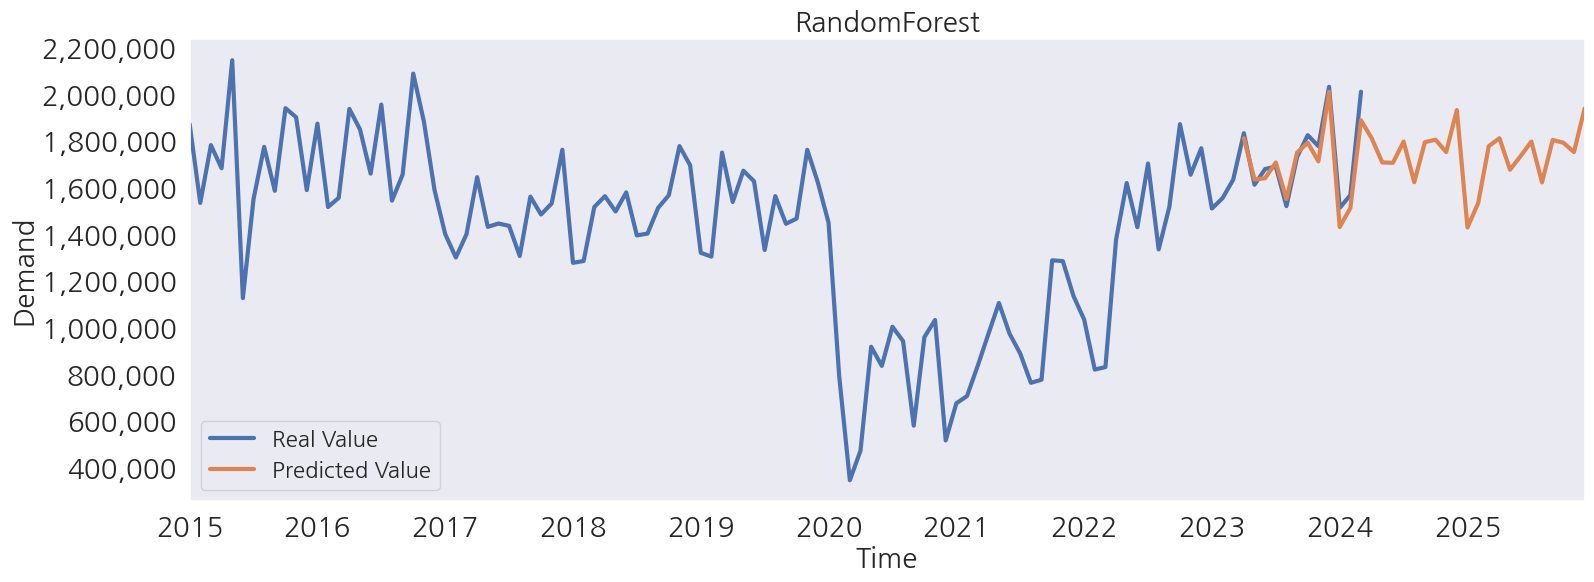

In [24]:
## 최종 미래 수요 예측
TARGET_ALGORITHM = 'RandomForest'
evaluation_time_PredPlot(pd.concat([df_train[Y_colname], df_validate[Y_colname]], axis=0),
                                    pd.concat([Y_valpred[TARGET_ALGORITHM], Y_tepred[TARGET_ALGORITHM]], axis=0),
                                    Y_pred_index=True,
                                    title=TARGET_ALGORITHM, xlabel='Time', ylabel='Demand', visual_package='matolotlib')